# **GATHERING DATASET**

# Dataset yang Digunakan

Dataset yang digunakan pada proyek ini adalah **Heart Attack risk Dataset**.
Dataset ini berisi data kesehatan pasien yang berkaitan dengan risiko penyakit kardiovaskular. Data tersebut digunakan untuk membangun model prediksi tingkat risiko penyakit jantung berdasarkan beberapa parameter kesehatan.

## Sumber Dataset
Dataset diperoleh dari Kaggle melalui tautan berikut:
[cardiovascular_risk_dataset.csv - Kaggle](https://www.kaggle.com/datasets/vishardmehta/heart-risk-progression-dataset/data)

# **DATA DICTIONARY**

## Data Dictionary - Heart Risk Progression Dataset

Dataset ini merupakan data sintetis yang digunakan untuk penelitian dan eksperimen machine learning terkait risiko penyakit jantung.

| No | Feature | Tipe Data | Jenis Variabel | Deskripsi | Rentang / Nilai | Contoh |
|---|---|---|---|---|---|---|
| 1 | `Patient_ID` | Integer | Identifier | ID unik untuk setiap pasien | 1 – 5500 | 1, 2, 3 |
| 2 | `age` | Integer | Numerical | Usia pasien dalam tahun | 18 – 90 | 62, 54, 46 |
| 3 | `bmi` | Float | Numerical | Body Mass Index (BMI), indikator lemak tubuh berdasarkan tinggi dan berat badan | ~16 – 40 | 25.0, 29.7 |
| 4 | `systolic_bp` | Integer | Numerical | Tekanan darah sistolik pasien (mmHg) | ~111 – 183 | 142, 158 |
| 5 | `diastolic_bp` | Float | Numerical | Tekanan darah diastolik pasien (mmHg) | ~69 – 120 | 93, 101 |
| 6 | `cholesterol_mg_dl` | Integer | Numerical | Total kadar kolesterol dalam darah (mg/dL) | ~160 – 320 | 247, 254 |
| 7 | `resting_heart_rate` | Float | Numerical | Detak jantung saat istirahat (Beats per minute (BPM)) | ~56 – 92 | 72, 74 |
| 8 | `smoking_status` | Object | Nominal | Status kebiasaan merokok pasien | Never, Former, Current | Never |
| 9 | `daily_steps` | Integer | Numerical | Rata-rata jumlah langkah per hari | ~500 – 14,000 | 11565, 4036 |
| 10 | `stress_level` | Integer | Ordinal | Tingkat stres pasien | 1 – 10 | 3, 8 |
| 11 | `physical_activity_hours_per_week` | Float | Numerical | Jumlah jam aktivitas fisik per minggu | 0 – 10 | 5.6, 0.5 |
| 12 | `sleep_hours` | Float | Numerical | Rata-rata durasi tidur per malam (jam) | ~4 – 9 | 8.2, 6.7 |
| 13 | `family_history_heart_disease` | Object | Binary | Menunjukkan apakah pasien memiliki riwayat keluarga penyakit jantung | Yes, No | Yes |
| 14 | `diet_quality_score` | Integer | Ordinal | Skor kualitas pola makan pasien | 1 – 10 | 7, 5 |
| 15 | `alcohol_units_per_week` | Float | Numerical | Konsumsi alkohol per minggu | 0 – ~11 | 0.7, 4.5 |
| 16 | `heart_disease_risk_score` | Float | Numerical (Target) | Skor risiko penyakit jantung yang dihitung | 0 – 100 | 28.1, 63.0 |
| 17 | `risk_category` | Object | Ordinal (Target) | Kategori risiko penyakit jantung | Low, Medium, High | Medium |

## Library

In [13]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Assessing Data**

## Import Data

In [14]:
df = pd.read_csv('/content/cardiovascular_risk_dataset.csv')
display(df.head())

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        5500 non-null   int64  
 1   age                               5500 non-null   int64  
 2   bmi                               5500 non-null   float64
 3   systolic_bp                       5500 non-null   int64  
 4   diastolic_bp                      5500 non-null   int64  
 5   cholesterol_mg_dl                 5500 non-null   int64  
 6   resting_heart_rate                5500 non-null   int64  
 7   smoking_status                    5500 non-null   object 
 8   daily_steps                       5500 non-null   int64  
 9   stress_level                      5500 non-null   int64  
 10  physical_activity_hours_per_week  5500 non-null   float64
 11  sleep_hours                       5500 non-null   float64
 12  family

* Dataset memiliki **5.500 baris data** dan **17 kolom**.
* Setiap baris merepresentasikan data satu pasien.
* Semua kolom memiliki **5.500 data non-null**, sehingga tidak terdapat missing value.


In [16]:
df.head()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


In [17]:
df.shape

(5500, 17)

In [18]:
df.describe()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score
count,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,2750.500000,53.872000,28.170818,147.248182,95.756727,239.684182,74.075091,5902.929455,4.907091,3.299364,6.869364,5.162909,3.782200,37.540455
std,1587.857571,21.196017,4.189877,13.222701,9.451559,28.570177,6.392166,3041.084590,2.298173,2.672457,1.091263,2.286134,3.515594,24.287026
min,1.000000,18.000000,15.000000,108.000000,64.000000,147.000000,48.000000,500.000000,1.000000,0.000000,4.000000,1.000000,0.000000,0.000000
25%,1375.750000,36.000000,25.200000,138.000000,89.000000,220.000000,70.000000,3428.000000,3.000000,1.200000,6.200000,3.000000,1.200000,18.400000
50%,2750.500000,54.000000,28.400000,147.000000,96.000000,240.000000,74.000000,5460.000000,5.000000,2.600000,6.900000,5.000000,2.800000,36.700000
75%,4125.250000,72.000000,31.100000,156.000000,102.000000,260.000000,79.000000,7772.000000,7.000000,4.900000,7.600000,7.000000,5.300000,55.500000
max,5500.000000,90.000000,40.900000,192.000000,120.000000,331.000000,92.000000,16793.000000,10.000000,12.900000,10.000000,10.000000,29.200000,100.000000


# **CLEANING DATA**

## Missing value

In [19]:
df.isnull().sum()

,0
Patient_ID,0
age,0
bmi,0
systolic_bp,0
diastolic_bp,0
cholesterol_mg_dl,0
resting_heart_rate,0
smoking_status,0
daily_steps,0
stress_level,0


* Semua kolom memiliki **5.500 data non-null**, sehingga tidak terdapat missing value.

## Cek Duplicate

In [20]:
df.duplicated().sum()

np.int64(0)

* Berdasarkan hasil pengecekan, tidak ditemukan data duplikat pada dataset.
* Artinya, setiap baris data memiliki informasi yang unik dan tidak ada data pasien yang tercatat lebih dari satu kali.
* Karena tidak terdapat duplikasi, tidak perlu dilakukan proses penghapusan data duplikat.
* Kondisi ini menunjukkan bahwa dataset sudah cukup baik dari sisi keunikan data dan dapat dilanjutkan ke tahap analisis berikutnya.

## Outlier

In [21]:
kolom_numerik = [
    'age',
    'bmi',
    'systolic_bp',
    'diastolic_bp',
    'cholesterol_mg_dl',
    'resting_heart_rate',
    'daily_steps',
    'physical_activity_hours_per_week',
    'sleep_hours',
    'alcohol_units_per_week'
]

In [22]:
outlier_summary = []

for col in kolom_numerik:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_summary.append({
        "Column": col,
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": round(outlier_percentage, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Column,Outlier Count,Outlier Percentage (%)
0,age,0,0.00
1,bmi,9,0.16
2,systolic_bp,15,0.27
3,diastolic_bp,5,0.09
4,cholesterol_mg_dl,7,0.13
5,resting_heart_rate,17,0.31
6,daily_steps,21,0.38
7,physical_activity_hours_per_week,42,0.76
8,sleep_hours,81,1.47
9,alcohol_units_per_week,214,3.89


* Berdasarkan hasil deteksi outlier, sebagian besar variabel memiliki jumlah outlier yang relatif kecil.


### Penanganan outlier

In [23]:
# Kolom numerik yang ingin ditangani outlier-nya
numeric_cols = [
    'bmi',
    'systolic_bp',
    'diastolic_bp',
    'cholesterol_mg_dl',
    'resting_heart_rate',
    'daily_steps',
    'physical_activity_hours_per_week',
    'sleep_hours',
    'alcohol_units_per_week'
]

# Salinan dataframe
df_clean = df.copy()

# Capping outlier menggunakan metode IQR
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

Outlier pada dataset ditangani menggunakan metode **IQR Capping**. Metode ini bekerja dengan membatasi nilai ekstrem berdasarkan batas bawah dan batas atas dari perhitungan **Interquartile Range (IQR)**.


In [24]:
outlier_summary_df_clean = []

for col in kolom_numerik:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    outlier_percentage = (outlier_count / len(df_clean)) * 100

    outlier_summary_df_clean.append({
        "Column": col,
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": round(outlier_percentage, 2)
    })

outlier_df_clean = pd.DataFrame(outlier_summary_df_clean)
outlier_df_clean

,Column,Outlier Count,Outlier Percentage (%)
0,age,0,0.0
1,bmi,0,0.0
2,systolic_bp,0,0.0
3,diastolic_bp,0,0.0
4,cholesterol_mg_dl,0,0.0
5,resting_heart_rate,0,0.0
6,daily_steps,0,0.0
7,physical_activity_hours_per_week,0,0.0
8,sleep_hours,0,0.0
9,alcohol_units_per_week,0,0.0


* Setelah dilakukan proses penanganan outlier, seluruh variabel numerik memiliki jumlah outlier sebesar **0**.
* Persentase outlier pada semua variabel juga menjadi **0,00%**.
* Hal ini menunjukkan bahwa nilai ekstrem pada dataset sudah berhasil ditangani.


# **PERTANYAAN BISNIS**

## Business Questions

1.	Berapa persentase pasien pada setiap kategori risiko kardiovaskular (Low, Medium, dan High) dalam dataset?

2.	Kelompok usia mana yang memiliki proporsi pasien High Risk paling besar?

3.	Bagaimana rata-rata tekanan darah, kadar kolesterol, dan heart_disease_risk_score pada setiap kategori risiko?

4.	Bagaimana pola gaya hidup pasien berdasarkan kategori risiko, dilihat dari aktivitas fisik, jumlah langkah harian, durasi tidur, kualitas diet, dan konsumsi alkohol?

5.	Bagaimana proporsi status merokok dan riwayat keluarga penyakit jantung pada setiap kategori risiko?

6.	Fitur klinis dan gaya hidup apa yang paling menonjol pada pasien kategori High Risk berdasarkan hasil EDA?

7.	Kelompok pasien mana yang perlu diprioritaskan dalam edukasi dan pencegahan penyakit jantung?


# **EDA**

In [25]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        5500 non-null   int64  
 1   age                               5500 non-null   int64  
 2   bmi                               5500 non-null   float64
 3   systolic_bp                       5500 non-null   int64  
 4   diastolic_bp                      5500 non-null   float64
 5   cholesterol_mg_dl                 5500 non-null   int64  
 6   resting_heart_rate                5500 non-null   float64
 7   smoking_status                    5500 non-null   object 
 8   daily_steps                       5500 non-null   int64  
 9   stress_level                      5500 non-null   int64  
 10  physical_activity_hours_per_week  5500 non-null   float64
 11  sleep_hours                       5500 non-null   float64
 12  family

## Target Variable Exploration

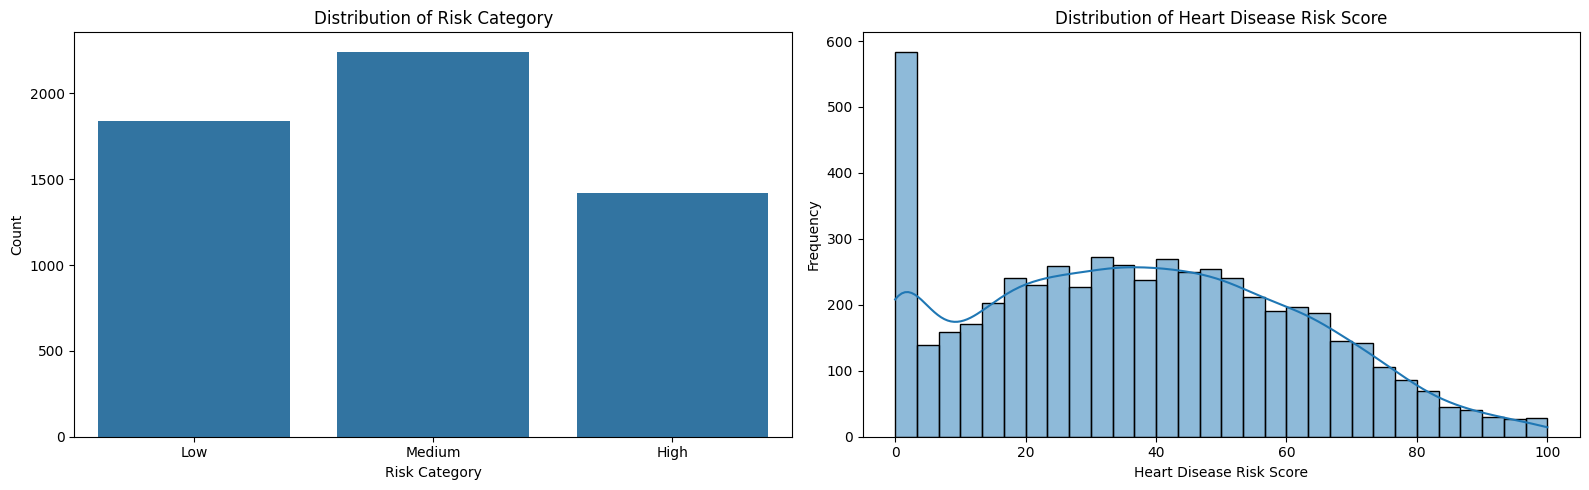

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Countplot risk category
sns.countplot(
    data=df_clean,
    x='risk_category',
    order=['Low', 'Medium', 'High'],
    ax=axes[0]
)

axes[0].set_title('Distribution of Risk Category')
axes[0].set_xlabel('Risk Category')
axes[0].set_ylabel('Count')

# Plot 2: Histogram risk score
sns.histplot(
    data=df_clean,
    x='heart_disease_risk_score',
    bins=30,
    kde=True,
    ax=axes[1]
)

axes[1].set_title('Distribution of Heart Disease Risk Score')
axes[1].set_xlabel('Heart Disease Risk Score')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

* Kategori **Medium Risk** memiliki jumlah pasien paling banyak.
* Kategori **Low Risk** berada di posisi kedua.
* Kategori **High Risk** memiliki jumlah pasien paling sedikit.
* Hal ini menunjukkan bahwa mayoritas pasien berada pada tingkat risiko sedang.
* Kelompok **Medium Risk** perlu diperhatikan karena berpotensi meningkat menjadi **High Risk**.
* Distribusi **heart disease risk score** berada pada rentang sekitar 0 sampai 100.
* Sebagian besar skor berada pada kategori rendah hingga sedang.
* Frekuensi pasien semakin menurun pada skor risiko yang tinggi.
* Pasien dengan skor risiko tinggi tetap perlu menjadi prioritas analisis dan pencegahan.


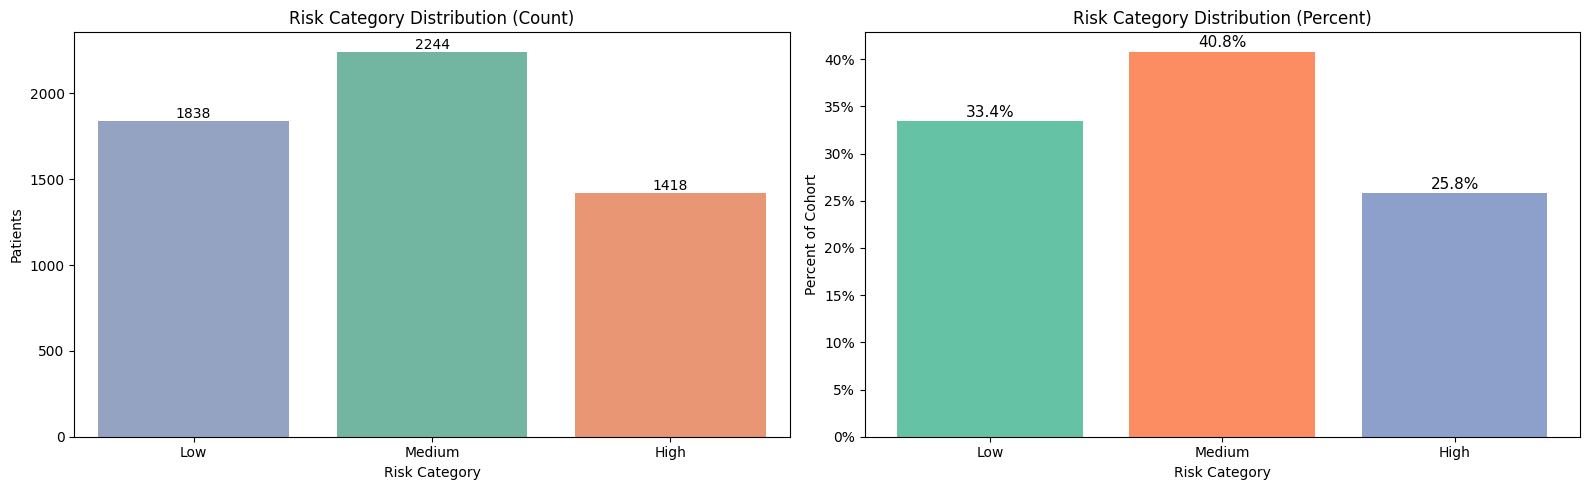

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

risk_order = ['Low', 'Medium', 'High']

risk_counts = df_clean['risk_category'].value_counts().reindex(risk_order)
risk_pct = (risk_counts / risk_counts.sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(
    data=df_clean,
    x='risk_category',
    hue='risk_category',
    order=risk_order,
    palette='Set2',
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Risk Category Distribution (Count)')
axes[0].set_xlabel('Risk Category')
axes[0].set_ylabel('Patients')

for container in axes[0].containers:
    axes[0].bar_label(container)

axes[1].bar(
    risk_order,
    risk_pct.values,
    color=sns.color_palette('Set2', 3)
)

axes[1].set_title('Risk Category Distribution (Percent)')
axes[1].set_xlabel('Risk Category')
axes[1].set_ylabel('Percent of Cohort')

axes[1].yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i, p in enumerate(risk_pct.values):
    axes[1].text(
        i,
        p + 0.5,
        f'{p:.1f}%',
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

* Kategori **Medium Risk** memiliki jumlah pasien terbanyak, yaitu **2.244 pasien** atau **40,8%**.
* Kategori **Low Risk** berada di posisi kedua dengan **1.838 pasien** atau **33,4%**.
* Kategori **High Risk** memiliki jumlah paling sedikit, yaitu **1.418 pasien** atau **25,8%**.
* Mayoritas pasien dalam dataset berada pada tingkat risiko **sedang**.
* Meskipun jumlah **High Risk** paling kecil, persentasenya tetap cukup besar sehingga perlu menjadi perhatian dalam analisis lanjutan.
* Kelompok **Medium Risk** juga penting diperhatikan karena berpotensi meningkat menjadi **High Risk** apabila faktor risiko tidak dikendalikan.


## Distribusi Variabel Numerik

In [28]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        5500 non-null   int64  
 1   age                               5500 non-null   int64  
 2   bmi                               5500 non-null   float64
 3   systolic_bp                       5500 non-null   int64  
 4   diastolic_bp                      5500 non-null   float64
 5   cholesterol_mg_dl                 5500 non-null   int64  
 6   resting_heart_rate                5500 non-null   float64
 7   smoking_status                    5500 non-null   object 
 8   daily_steps                       5500 non-null   int64  
 9   stress_level                      5500 non-null   int64  
 10  physical_activity_hours_per_week  5500 non-null   float64
 11  sleep_hours                       5500 non-null   float64
 12  family

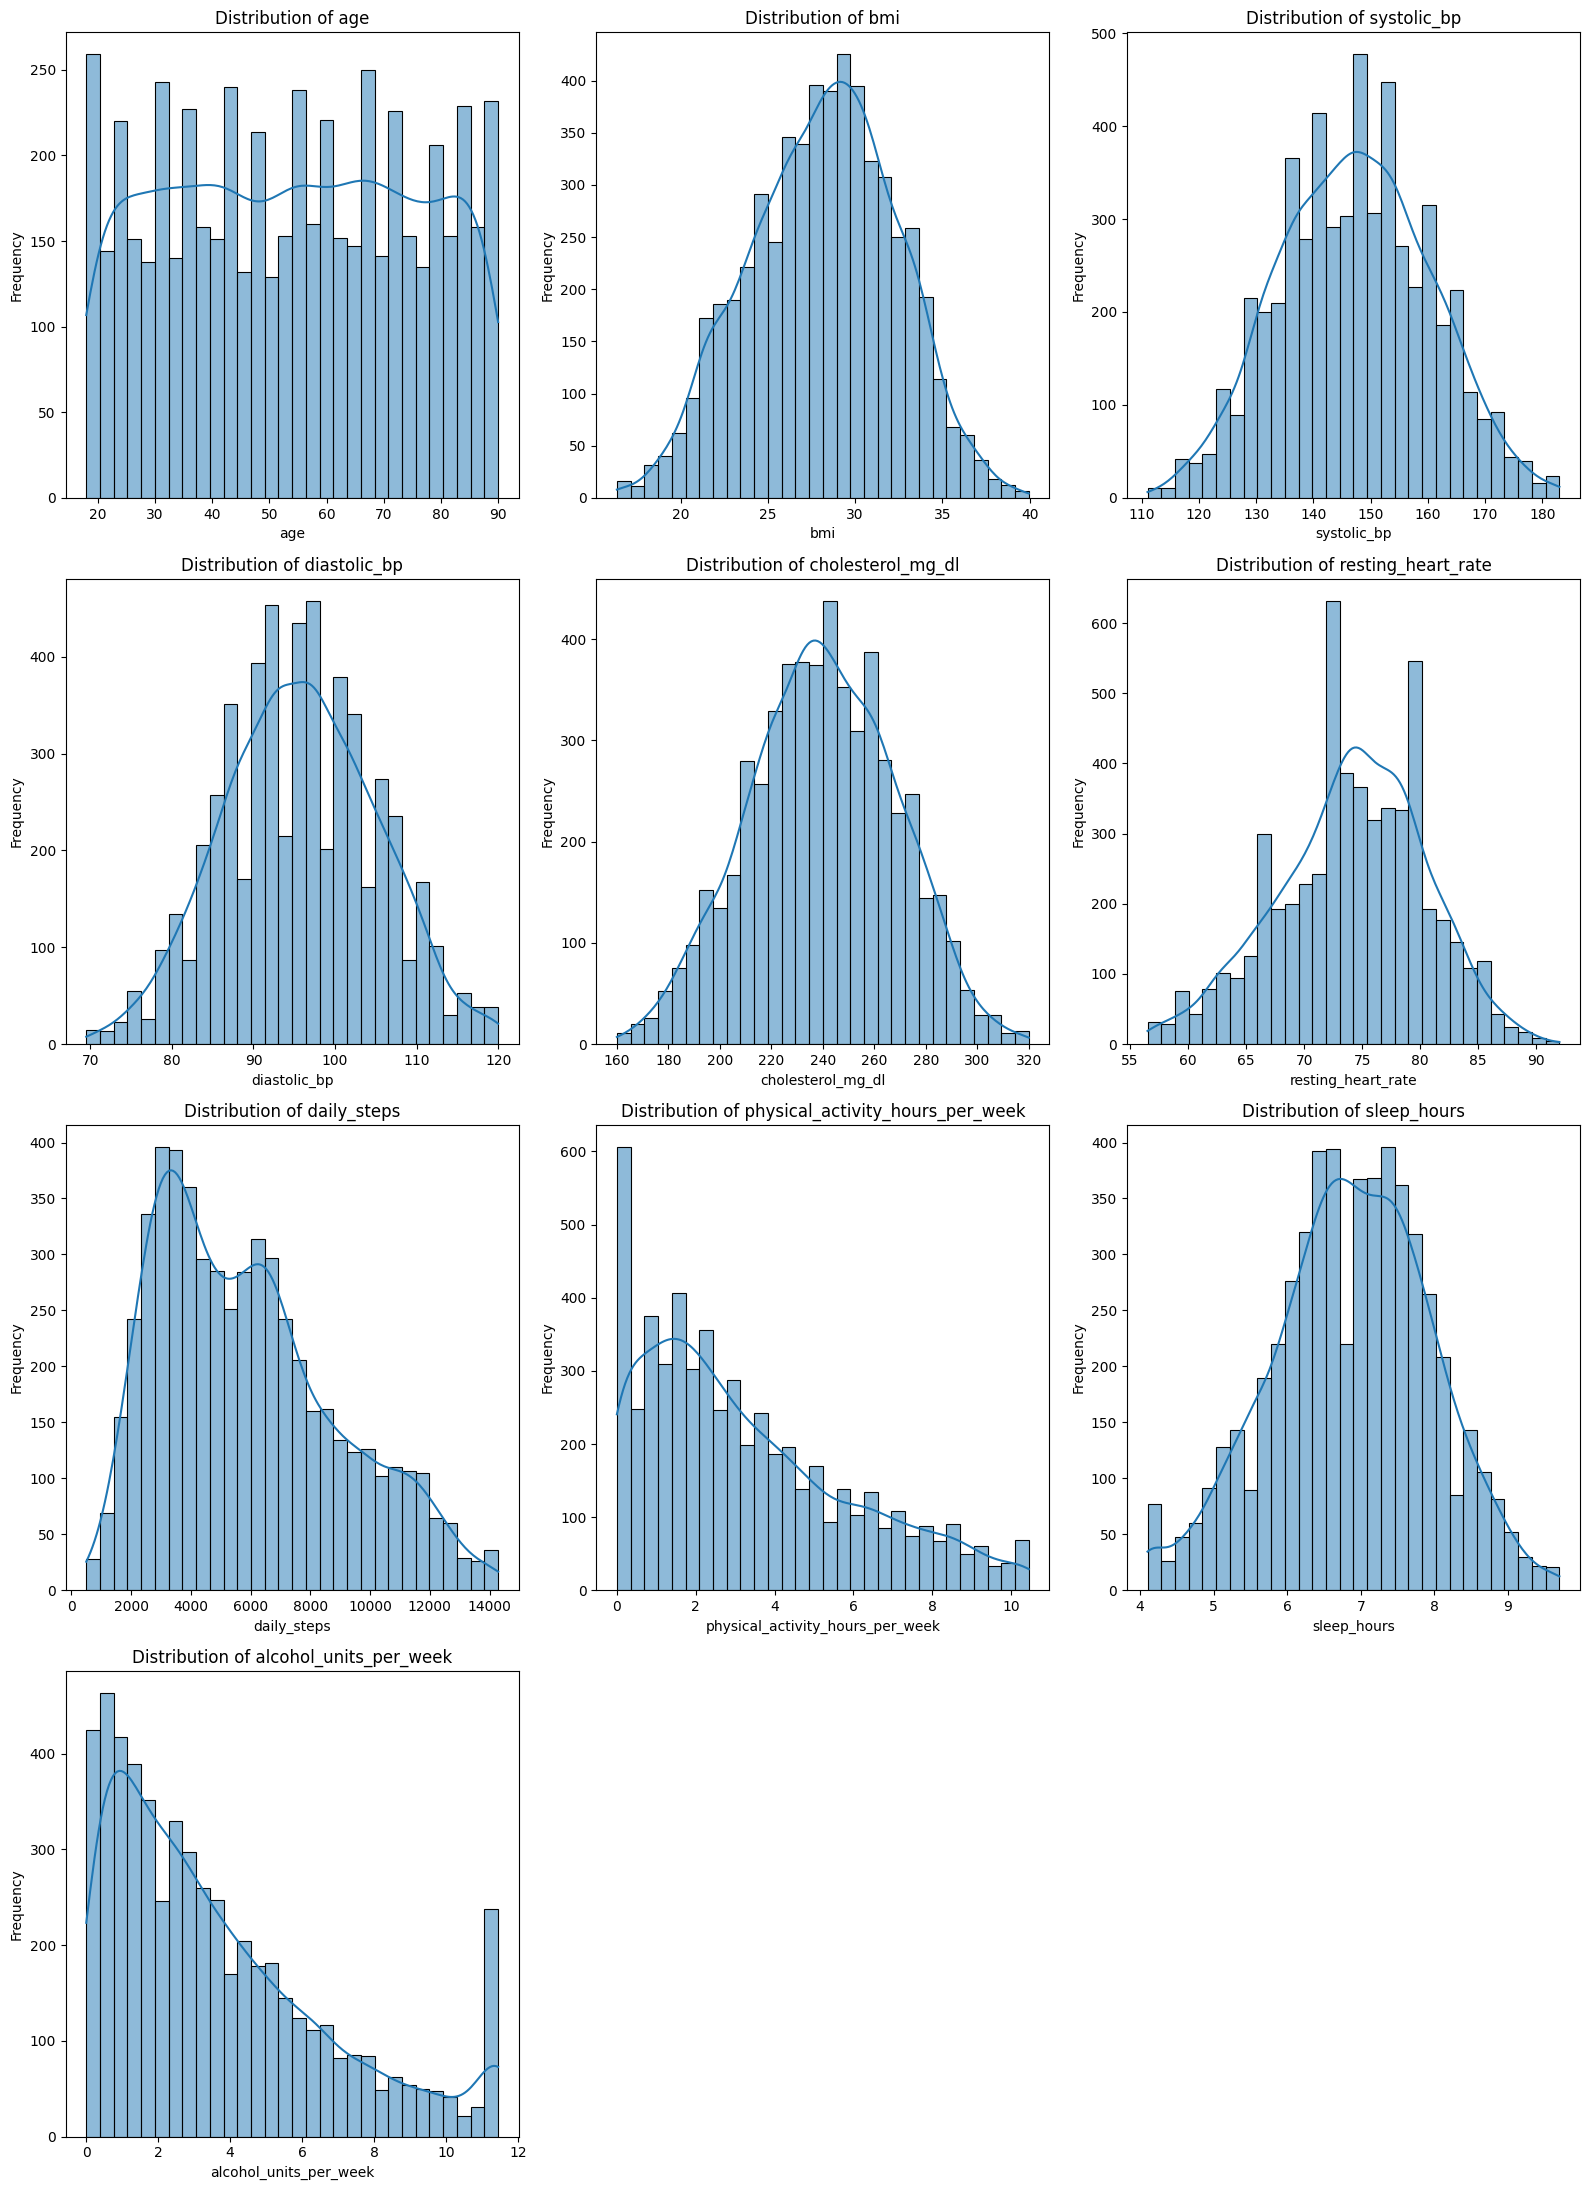

In [29]:
kolom_numerik = [
    'age',
    'bmi',
    'systolic_bp',
    'diastolic_bp',
    'cholesterol_mg_dl',
    'resting_heart_rate',
    'daily_steps',
    'physical_activity_hours_per_week',
    'sleep_hours',
    'alcohol_units_per_week'
]

fig, axes = plt.subplots(4, 3, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(kolom_numerik):
    sns.histplot(
        data=df_clean,
        x=col,
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hapus subplot kosong
for j in range(len(kolom_numerik), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* Variabel `age` tersebar cukup merata dari usia muda hingga usia lanjut.
* Variabel `bmi` cenderung membentuk distribusi normal dengan mayoritas nilai berada di sekitar 25–32.
* Variabel `systolic_bp` dan `diastolic_bp` juga cenderung normal, dengan sebagian besar pasien berada pada tekanan darah menengah.
* Variabel `cholesterol_mg_dl` memiliki pola distribusi cukup normal, dengan nilai terbanyak berada di sekitar 220–270 mg/dL.
* Variabel `resting_heart_rate` paling banyak berada pada kisaran 70–80 bpm.
* Variabel `daily_steps` cenderung condong ke kanan, artinya sebagian besar pasien memiliki jumlah langkah harian rendah hingga sedang.
* Variabel `physical_activity_hours_per_week` juga condong ke kanan, menunjukkan banyak pasien memiliki aktivitas fisik mingguan yang rendah.
* Variabel `sleep_hours` cenderung normal, dengan mayoritas pasien tidur sekitar 6–8 jam.
* Variabel `alcohol_units_per_week` condong ke kanan, menunjukkan sebagian besar pasien mengonsumsi alkohol dalam jumlah rendah.
* Secara umum, sebagian variabel klinis memiliki distribusi mendekati normal, sedangkan variabel gaya hidup lebih bervariasi dan cenderung tidak merata.


## Distribusi Varibel Katagorik

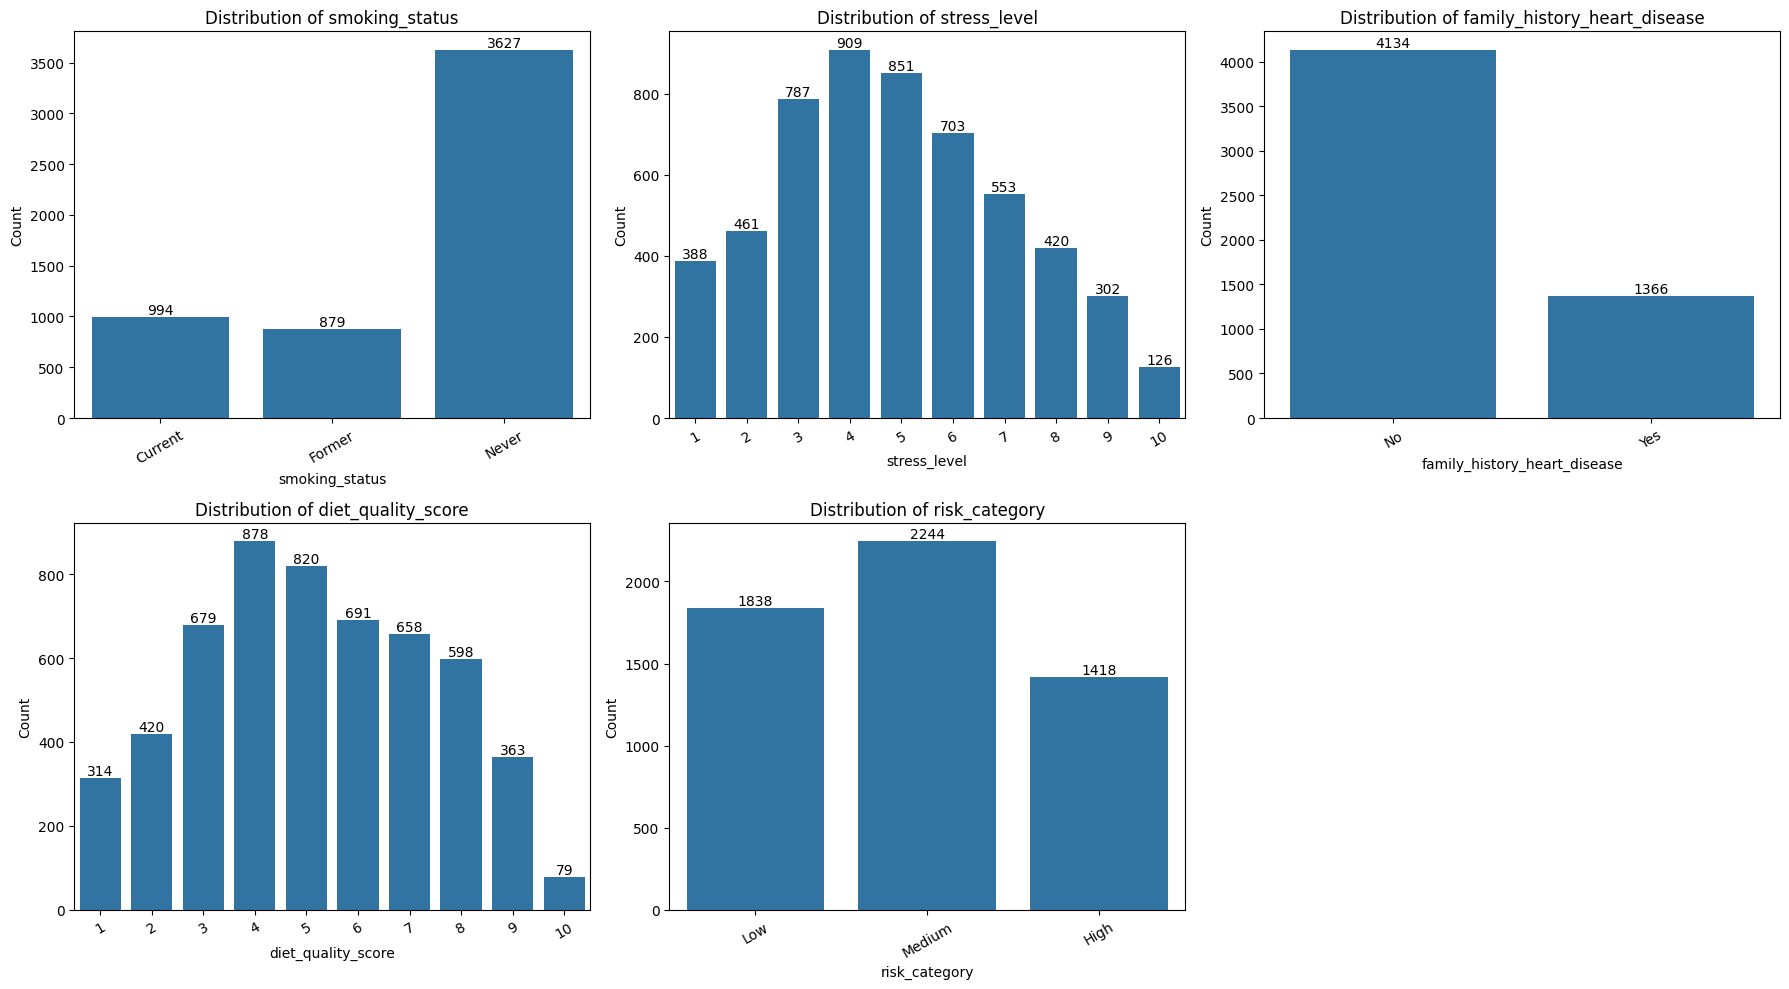

In [30]:
kolom_kategorik = [
    'smoking_status',
    'stress_level',
    'family_history_heart_disease',
    'diet_quality_score',
    'risk_category'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(kolom_kategorik):
    if col == 'risk_category':
        order = ['Low', 'Medium', 'High']
    else:
        order = sorted(df_clean[col].unique())

    sns.countplot(
        data=df_clean,
        x=col,
        order=order,
        ax=axes[i]
    )

    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

    for container in axes[i].containers:
        axes[i].bar_label(container)

# Hapus subplot kosong
for j in range(len(kolom_kategorik), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* Mayoritas pasien memiliki status merokok **Never**, yaitu sebanyak **3.627 pasien**.
* Jumlah pasien **Current smoker** sebanyak **994 pasien**, sedangkan **Former smoker** sebanyak **879 pasien**.
* Tingkat stres paling banyak berada pada level **4** dan **5**, sehingga mayoritas pasien memiliki tingkat stres sedang.
* Sebagian besar pasien tidak memiliki riwayat keluarga penyakit jantung, yaitu **4.134 pasien**.
* Pasien yang memiliki riwayat keluarga penyakit jantung berjumlah **1.366 pasien**.
* Skor kualitas diet paling banyak berada pada nilai **4** dan **5**, menunjukkan kualitas diet pasien cenderung sedang.
* Kategori risiko terbanyak adalah **Medium Risk** dengan **2.244 pasien**.
* Kategori **Low Risk** berjumlah **1.838 pasien**, sedangkan **High Risk** berjumlah **1.418 pasien**.
* Secara umum, dataset didominasi oleh pasien yang tidak merokok, tidak memiliki riwayat keluarga penyakit jantung, dan berada pada kategori risiko sedang.


## Korelasi variabel numerik

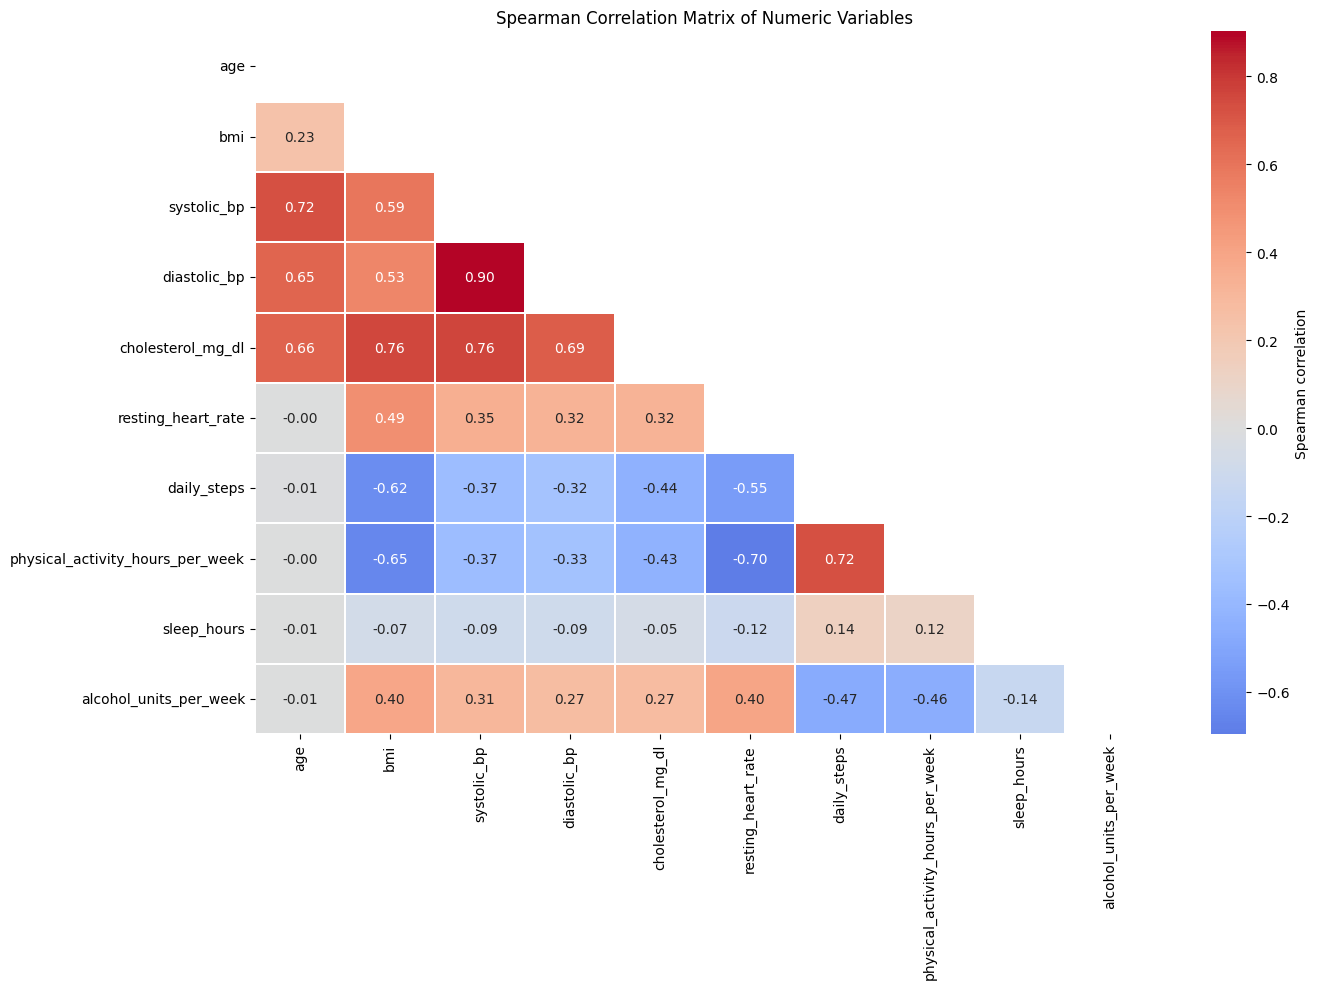

In [31]:
corr = df_clean[kolom_numerik].corr(method='spearman')

plt.figure(figsize=(14, 10))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.3,
    cbar_kws={'label': 'Spearman correlation'}
)

plt.title('Spearman Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()

* Korelasi terkuat terdapat antara `systolic_bp` dan `diastolic_bp` sebesar **0,90**, menunjukkan hubungan positif yang sangat kuat.
* `cholesterol_mg_dl` memiliki korelasi positif cukup kuat dengan `bmi`, `systolic_bp`, dan `diastolic_bp`.
* `age` berkorelasi positif dengan tekanan darah dan kolesterol, artinya semakin tinggi usia, nilai tekanan darah dan kolesterol cenderung meningkat.
* `daily_steps` dan `physical_activity_hours_per_week` memiliki korelasi positif sebesar **0,72**, menunjukkan bahwa pasien yang lebih aktif cenderung memiliki jumlah langkah harian lebih tinggi.
* `physical_activity_hours_per_week` berkorelasi negatif dengan `resting_heart_rate` sebesar **-0,70**, artinya semakin tinggi aktivitas fisik, detak jantung istirahat cenderung lebih rendah.
* `bmi` memiliki korelasi negatif dengan `daily_steps` dan `physical_activity_hours_per_week`, menunjukkan bahwa pasien dengan BMI lebih tinggi cenderung memiliki aktivitas fisik lebih rendah.
* `alcohol_units_per_week` berkorelasi negatif dengan `daily_steps` dan aktivitas fisik, sehingga konsumsi alkohol yang lebih tinggi cenderung berkaitan dengan gaya hidup yang kurang aktif.
* `sleep_hours` memiliki korelasi yang lemah dengan sebagian besar variabel, sehingga hubungannya tidak terlalu kuat dalam dataset ini.
* Secara umum, variabel klinis seperti tekanan darah, BMI, dan kolesterol saling berkorelasi positif, sedangkan variabel aktivitas fisik cenderung berkorelasi negatif dengan faktor risiko kesehatan.


### Korelasi Variabel Numerik dengan Target Numerik

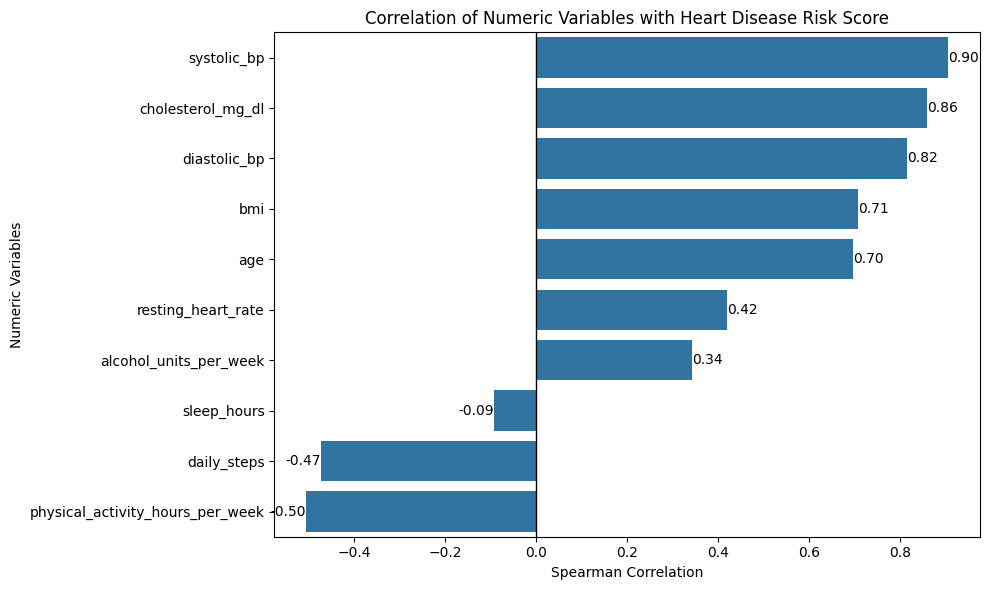

In [32]:
target = 'heart_disease_risk_score'

corr_target = (
    df_clean[kolom_numerik + [target]]
    .corr(method='spearman')[target]
    .drop(target)
    .sort_values(ascending=False)
)

corr_target

plt.figure(figsize=(10, 6))

sns.barplot(
    x=corr_target.values,
    y=corr_target.index
)

plt.axvline(0, color='black', linewidth=1)

plt.title('Correlation of Numeric Variables with Heart Disease Risk Score')
plt.xlabel('Spearman Correlation')
plt.ylabel('Numeric Variables')

for i, value in enumerate(corr_target.values):
    plt.text(
        value,
        i,
        f'{value:.2f}',
        va='center',
        ha='left' if value >= 0 else 'right'
    )

plt.tight_layout()
plt.show()

* `systolic_bp` memiliki korelasi positif paling kuat dengan skor risiko penyakit jantung, yaitu **0,90**.
* `cholesterol_mg_dl` juga memiliki korelasi positif sangat kuat sebesar **0,86**.
* `diastolic_bp` berkorelasi positif kuat dengan nilai **0,82**.
* `bmi` dan `age` juga memiliki hubungan positif yang cukup kuat dengan skor risiko.
* Artinya, semakin tinggi tekanan darah, kolesterol, BMI, dan usia, maka skor risiko penyakit jantung cenderung meningkat.
* `resting_heart_rate` dan `alcohol_units_per_week` memiliki korelasi positif sedang hingga lemah.
* `physical_activity_hours_per_week` memiliki korelasi negatif sebesar **-0,50**.
* `daily_steps` juga memiliki korelasi negatif sebesar **-0,47**.
* Artinya, semakin tinggi aktivitas fisik dan jumlah langkah harian, maka skor risiko penyakit jantung cenderung menurun.
* `sleep_hours` memiliki korelasi negatif sangat lemah, sehingga hubungannya dengan skor risiko tidak terlalu kuat.


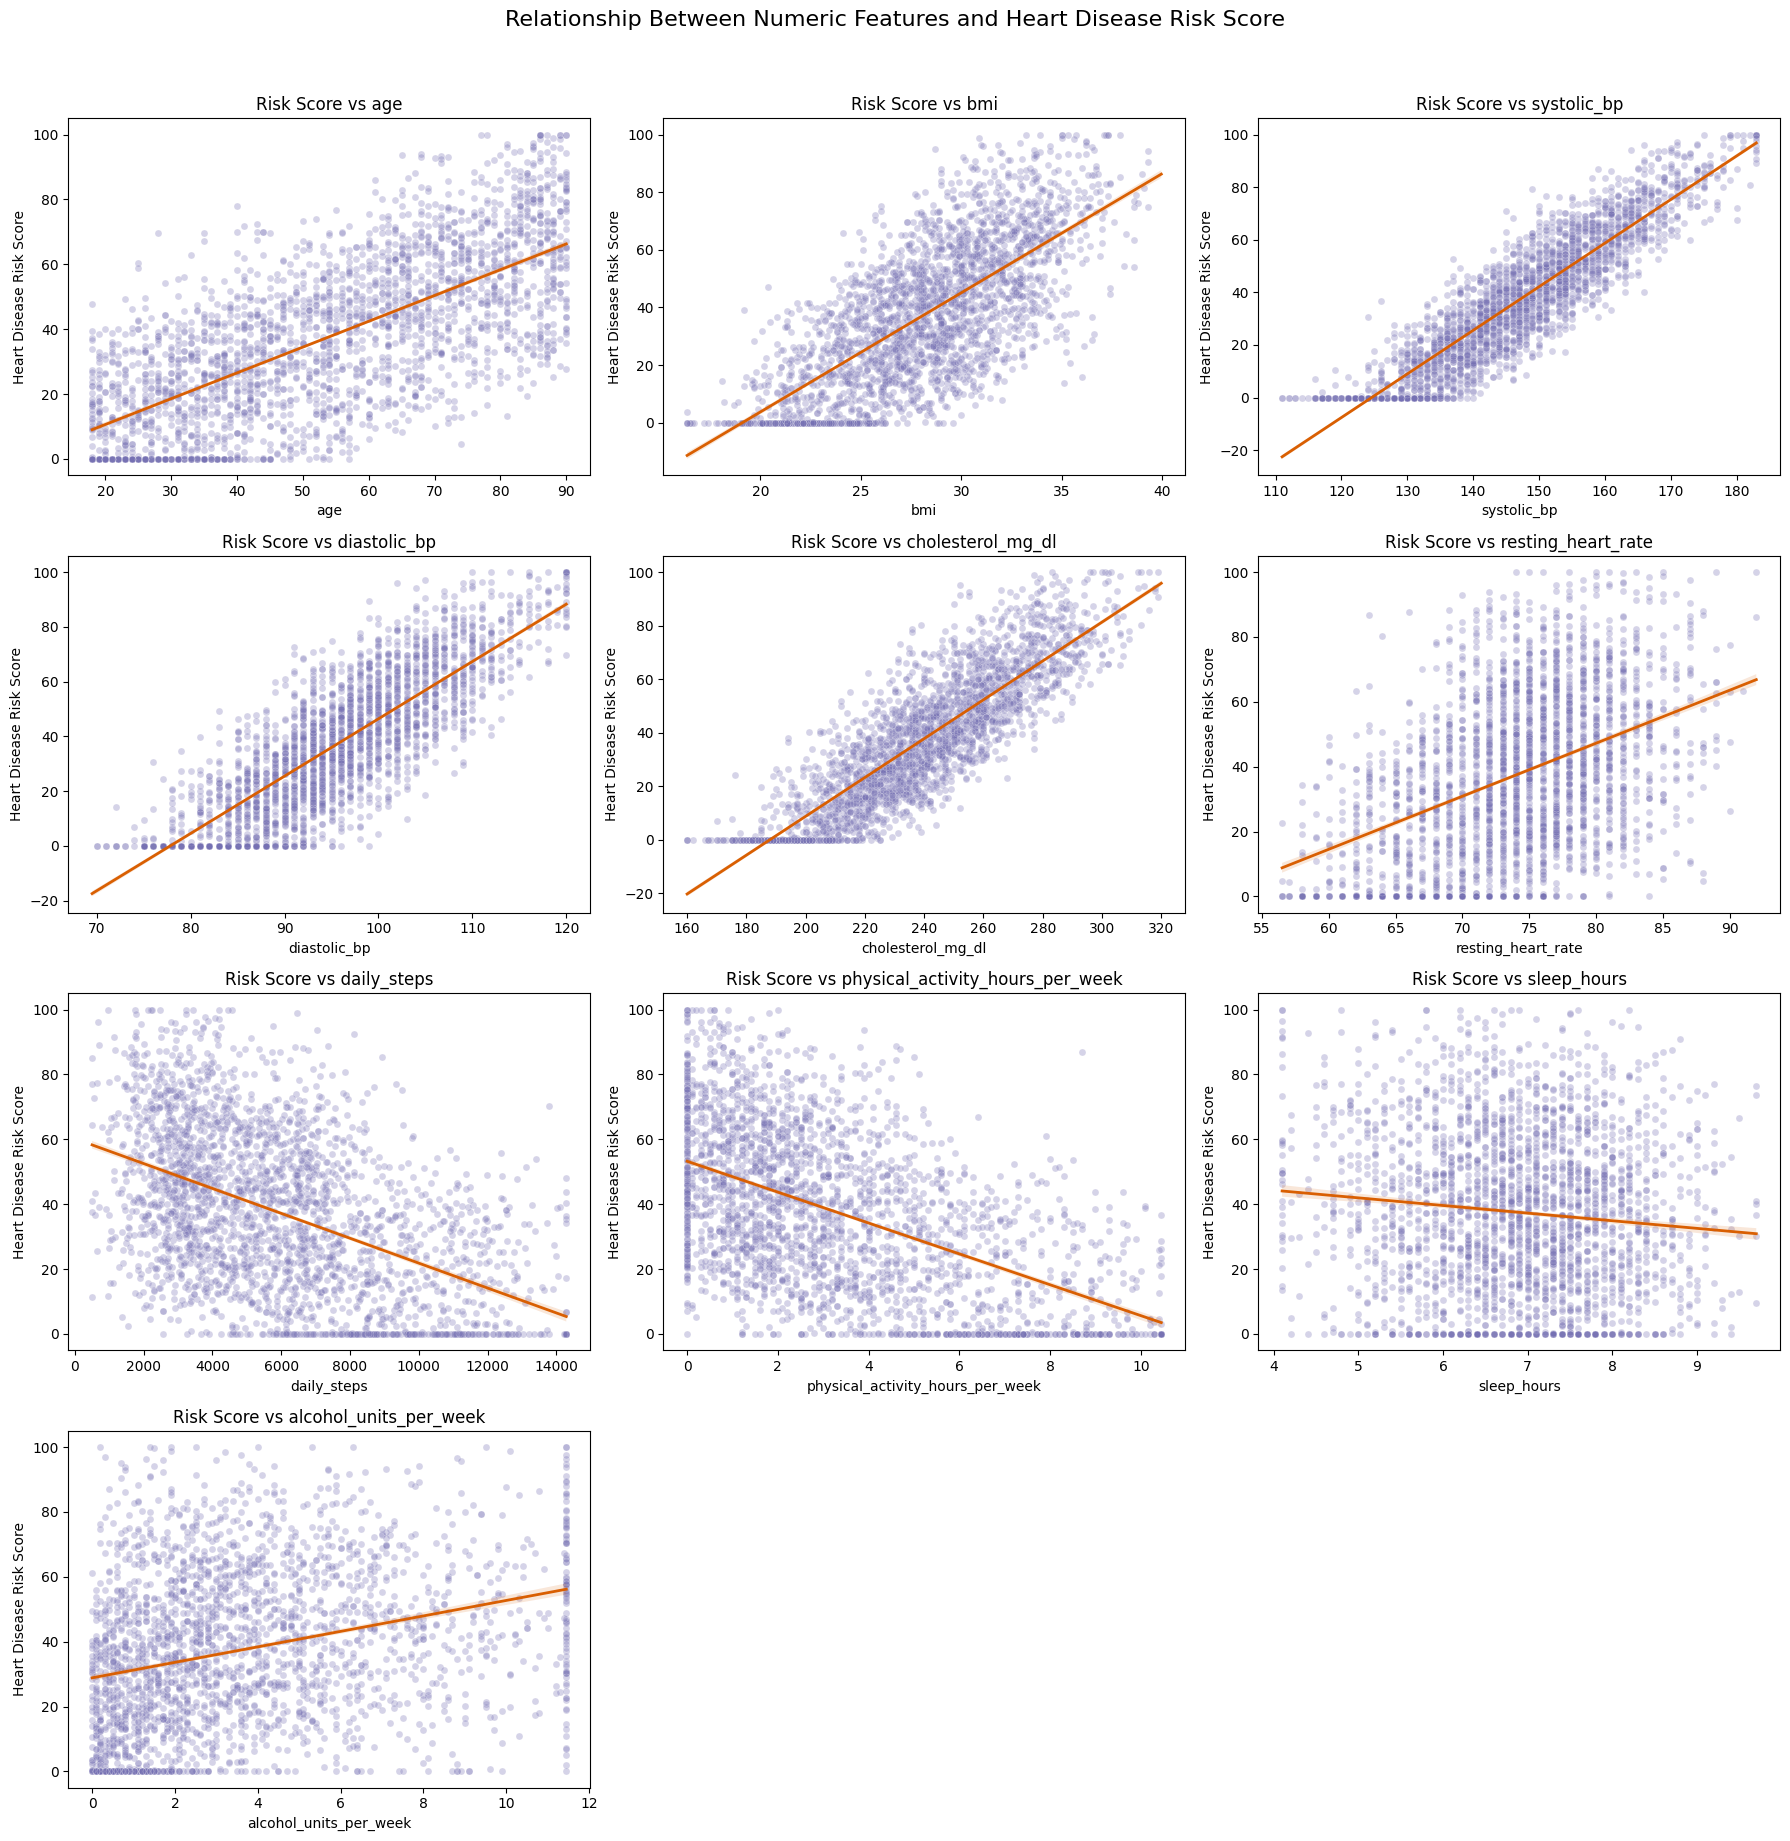

In [33]:
RANDOM_STATE = 42

n_cols = 3
n_rows = int(np.ceil(len(kolom_numerik) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
axes = axes.flatten()

sample_df = df_clean.sample(min(len(df_clean), 2500), random_state=RANDOM_STATE)

for i, col in enumerate(kolom_numerik):
    sns.scatterplot(
        data=sample_df,
        x=col,
        y='heart_disease_risk_score',
        alpha=0.3,
        s=25,
        color='#7570b3',
        ax=axes[i]
    )

    sns.regplot(
        data=df_clean,
        x=col,
        y='heart_disease_risk_score',
        scatter=False,
        color='#d95f02',
        line_kws={'linewidth': 2},
        ax=axes[i]
    )

    axes[i].set_title(f'Risk Score vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Heart Disease Risk Score')

for j in range(len(kolom_numerik), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Relationship Between Numeric Features and Heart Disease Risk Score', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

* `age` memiliki hubungan positif dengan skor risiko, artinya semakin tinggi usia maka risiko penyakit jantung cenderung meningkat.
* `bmi` juga menunjukkan hubungan positif, sehingga BMI yang lebih tinggi cenderung berkaitan dengan skor risiko yang lebih besar.
* `systolic_bp` dan `diastolic_bp` memiliki hubungan positif yang kuat dengan skor risiko.
* `cholesterol_mg_dl` juga menunjukkan pola positif yang jelas terhadap peningkatan risiko penyakit jantung.
* `resting_heart_rate` memiliki hubungan positif, tetapi tidak sekuat tekanan darah dan kolesterol.
* `daily_steps` memiliki hubungan negatif, artinya semakin banyak langkah harian maka skor risiko cenderung lebih rendah.
* `physical_activity_hours_per_week` juga memiliki hubungan negatif dengan skor risiko.
* `sleep_hours` menunjukkan hubungan negatif yang lemah, sehingga pengaruhnya tidak terlalu kuat.
* `alcohol_units_per_week` memiliki hubungan positif, artinya konsumsi alkohol yang lebih tinggi cenderung berkaitan dengan peningkatan skor risiko.
* Secara umum, faktor klinis seperti tekanan darah, kolesterol, BMI, dan usia cenderung meningkatkan risiko, sedangkan aktivitas fisik cenderung menurunkan risiko.


### Korelasi Varibel Numerik dengan Target Katagorik

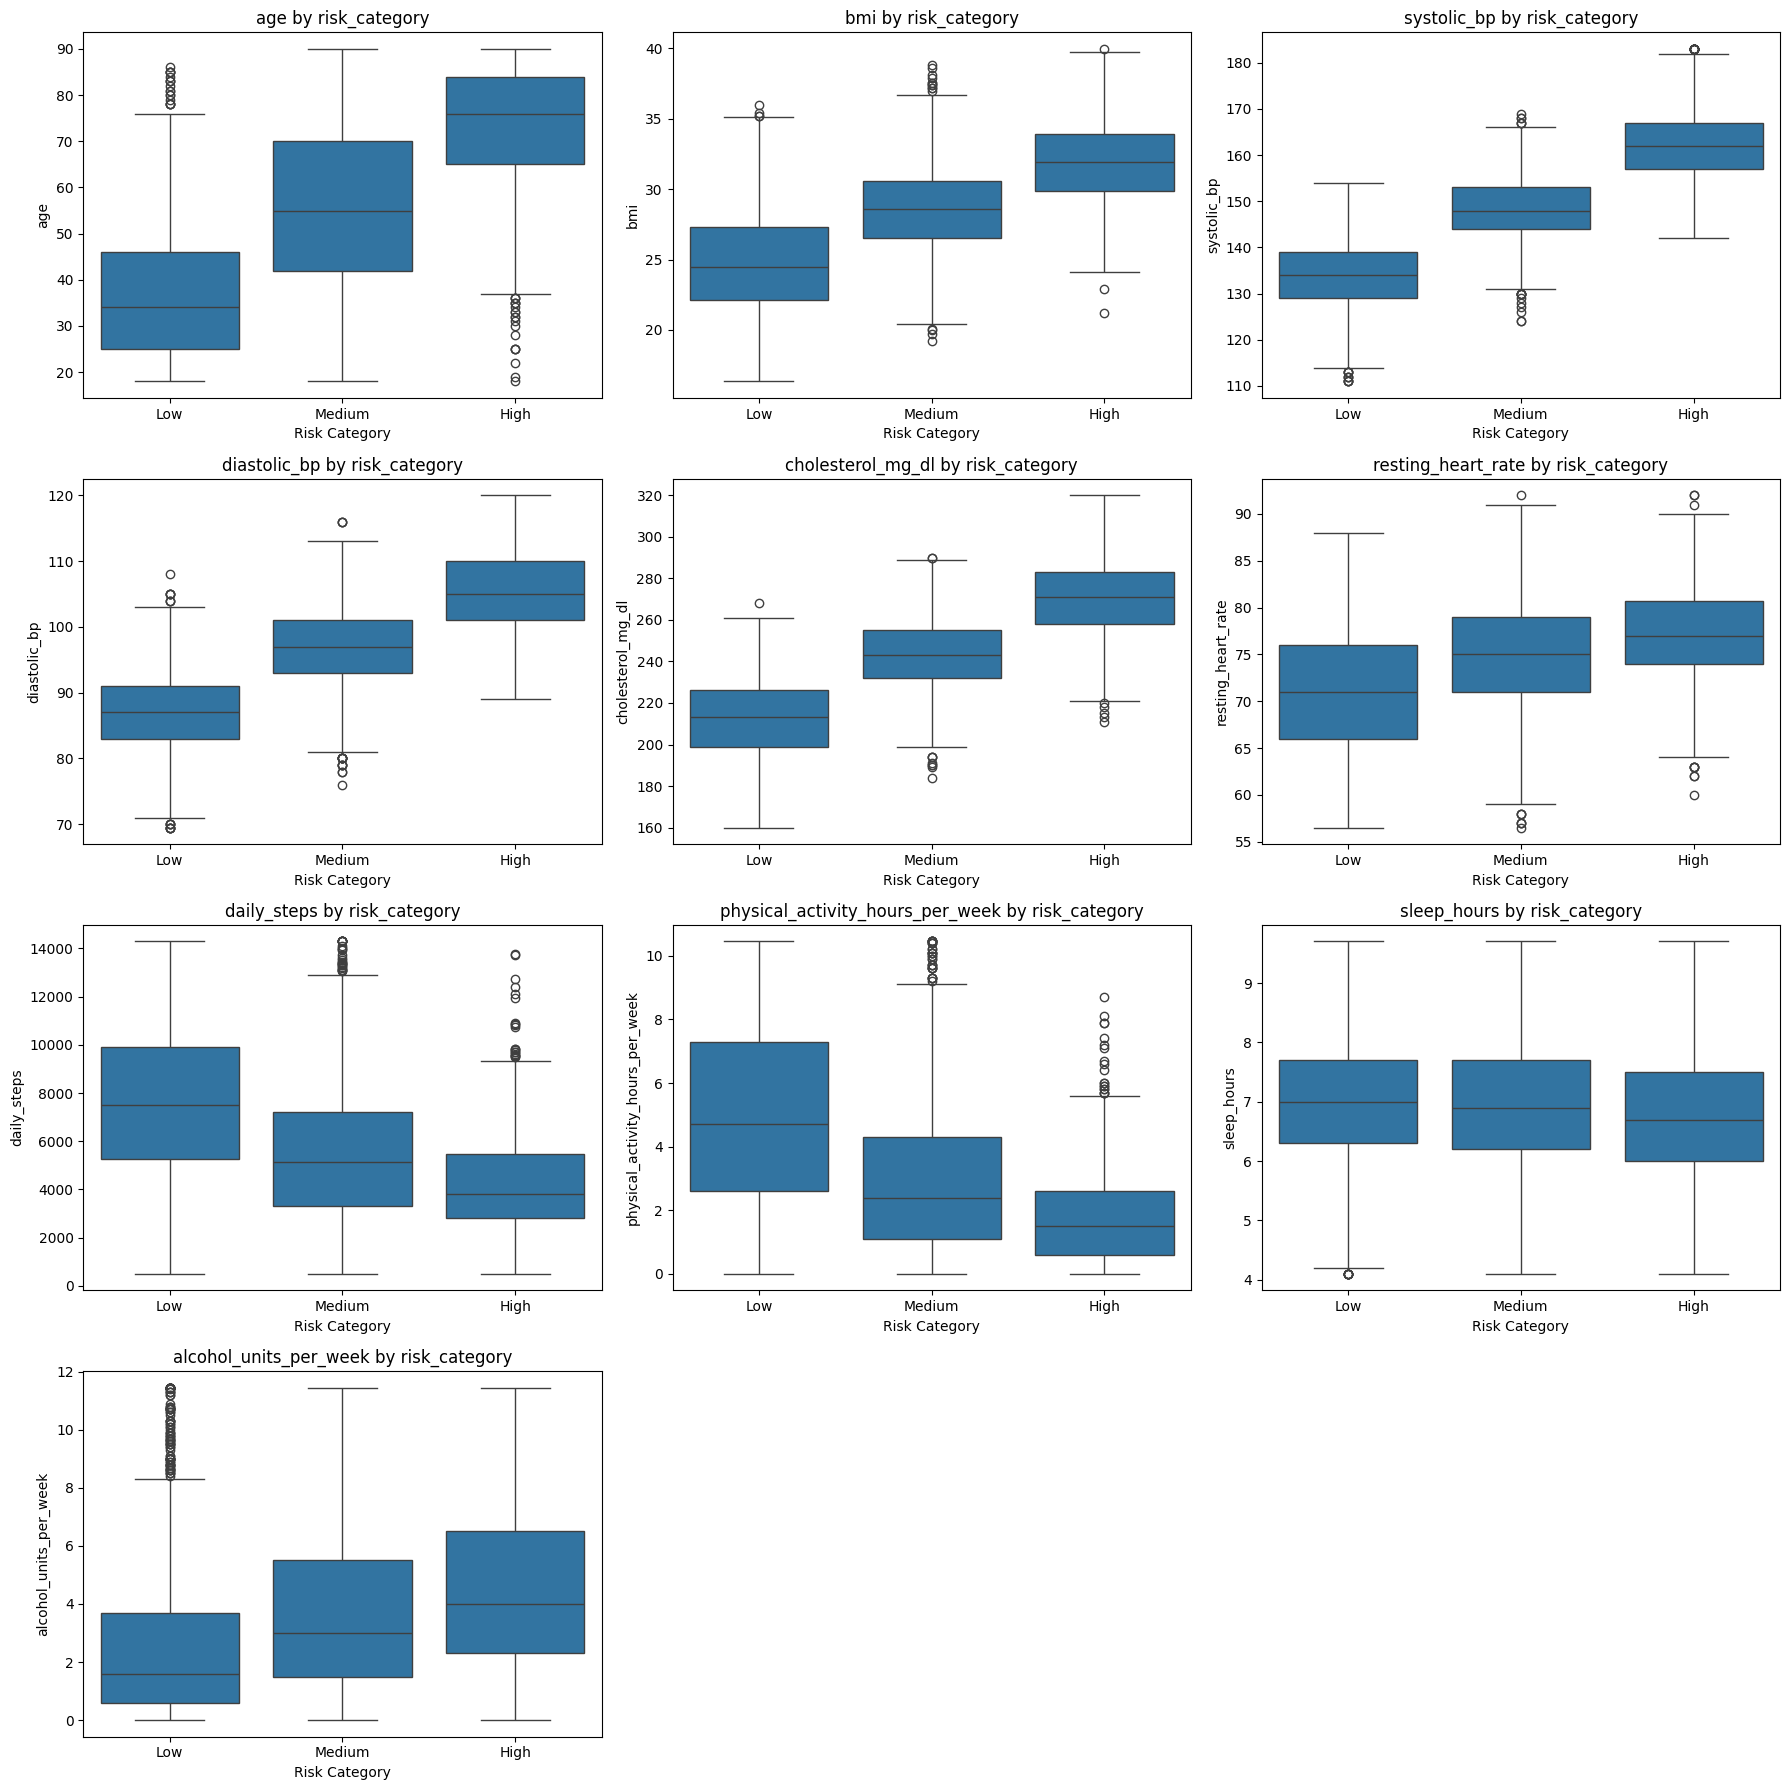

In [34]:
target = 'risk_category'

fig, axes = plt.subplots(4, 3, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(kolom_numerik):
    sns.boxplot(
        data=df_clean,
        x=target,
        y=col,
        order=['Low', 'Medium', 'High'],
        ax=axes[i]
    )

    axes[i].set_title(f'{col} by {target}')
    axes[i].set_xlabel('Risk Category')
    axes[i].set_ylabel(col)

# Hapus subplot kosong
for j in range(len(kolom_numerik), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* Pasien kategori **High Risk** cenderung memiliki usia lebih tinggi dibandingkan kategori **Low** dan **Medium**.
* Nilai `bmi` meningkat dari kategori **Low**, **Medium**, hingga **High Risk**.
* Tekanan darah `systolic_bp` dan `diastolic_bp` terlihat semakin tinggi pada kategori risiko yang lebih tinggi.
* Kadar `cholesterol_mg_dl` juga meningkat seiring naiknya kategori risiko.
* `resting_heart_rate` pada kategori **High Risk** cenderung lebih tinggi dibandingkan kategori lainnya.
* `daily_steps` semakin rendah pada kategori risiko yang lebih tinggi.
* `physical_activity_hours_per_week` juga menurun dari **Low Risk** ke **High Risk**.
* `sleep_hours` terlihat relatif mirip antar kategori, sehingga perbedaannya tidak terlalu kuat.
* `alcohol_units_per_week` cenderung lebih tinggi pada kategori **High Risk**.
* Secara umum, pasien **High Risk** memiliki faktor klinis yang lebih buruk, seperti usia, BMI, tekanan darah, kolesterol, dan detak jantung yang lebih tinggi.
* Sebaliknya, pasien **Low Risk** cenderung memiliki aktivitas fisik dan jumlah langkah harian yang lebih tinggi.


## Korelasi Varibel Katagorik

In [35]:
from scipy.stats import chi2_contingency

kolom_kategorik = [
    'smoking_status',
    'stress_level',
    'family_history_heart_disease',
    'diet_quality_score',
    'risk_category'
]

def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape

    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

categorical_corr_results = []

for i in range(len(kolom_kategorik)):
    for j in range(i + 1, len(kolom_kategorik)):
        col1 = kolom_kategorik[i]
        col2 = kolom_kategorik[j]

        score = cramers_v(df_clean[col1], df_clean[col2])

        categorical_corr_results.append({
            'Variable Pair': f'{col1} vs {col2}',
            "Cramer's V": round(score, 3)
        })

categorical_corr_df = pd.DataFrame(categorical_corr_results)
categorical_corr_df = categorical_corr_df.sort_values(
    by="Cramer's V",
    ascending=False
)

display(categorical_corr_df)

,Variable Pair,Cramer's V
9,diet_quality_score vs risk_category,0.355
3,smoking_status vs risk_category,0.276
6,stress_level vs risk_category,0.235
2,smoking_status vs diet_quality_score,0.175
0,smoking_status vs stress_level,0.162
8,family_history_heart_disease vs risk_category,0.140
5,stress_level vs diet_quality_score,0.135
4,stress_level vs family_history_heart_disease,0.036
7,family_history_heart_disease vs diet_quality_s...,0.035
1,smoking_status vs family_history_heart_disease,0.008


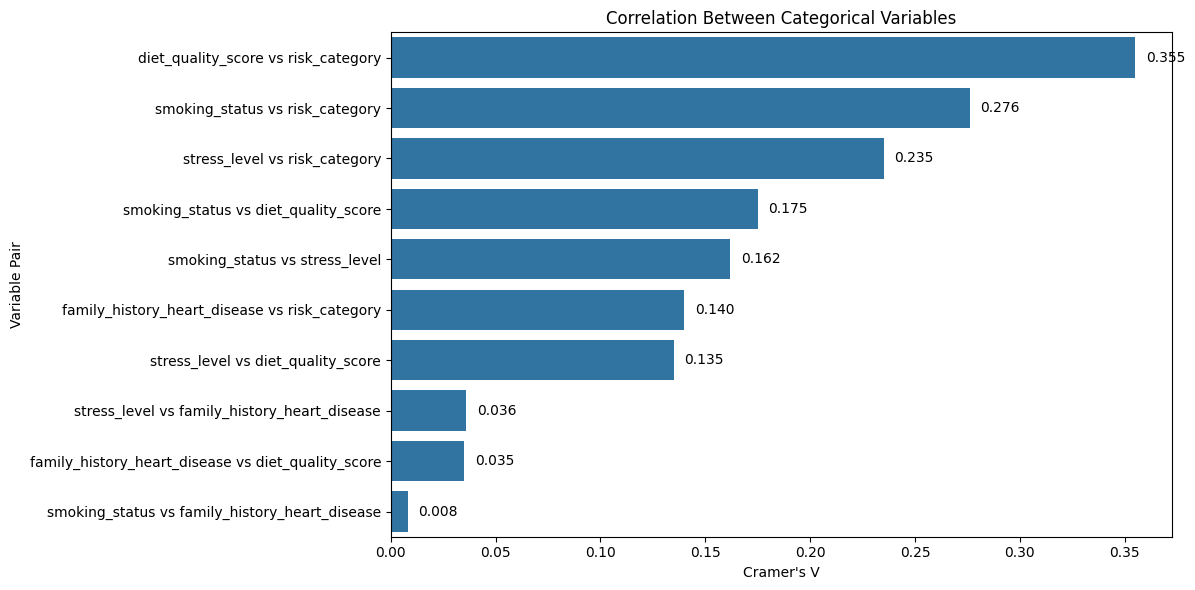

In [36]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=categorical_corr_df,
    x="Cramer's V",
    y='Variable Pair'
)

plt.title("Correlation Between Categorical Variables")
plt.xlabel("Cramer's V")
plt.ylabel("Variable Pair")

for i, value in enumerate(categorical_corr_df["Cramer's V"]):
    plt.text(
        value + 0.005,
        i,
        f'{value:.3f}',
        va='center'
    )

plt.tight_layout()
plt.show()

* Hubungan terkuat terdapat antara `diet_quality_score` dan `risk_category` dengan nilai **Cramer's V = 0,355**.
* Artinya, kualitas diet memiliki hubungan paling besar dengan kategori risiko dibandingkan variabel kategorik lainnya.
* `smoking_status` juga memiliki hubungan dengan `risk_category` sebesar **0,276**.
* `stress_level` memiliki hubungan dengan `risk_category` sebesar **0,235**.
* Hal ini menunjukkan bahwa pola makan, status merokok, dan tingkat stres cukup berkaitan dengan kategori risiko kardiovaskular.
* `family_history_heart_disease` memiliki hubungan yang lebih lemah dengan `risk_category`, yaitu **0,140**.
* Beberapa pasangan variabel memiliki nilai korelasi sangat kecil, seperti `smoking_status` dengan `family_history_heart_disease` sebesar **0,008**.
* Secara umum, variabel kategorik yang paling berpengaruh terhadap kategori risiko adalah **kualitas diet, status merokok, dan tingkat stres**.


In [57]:
import math

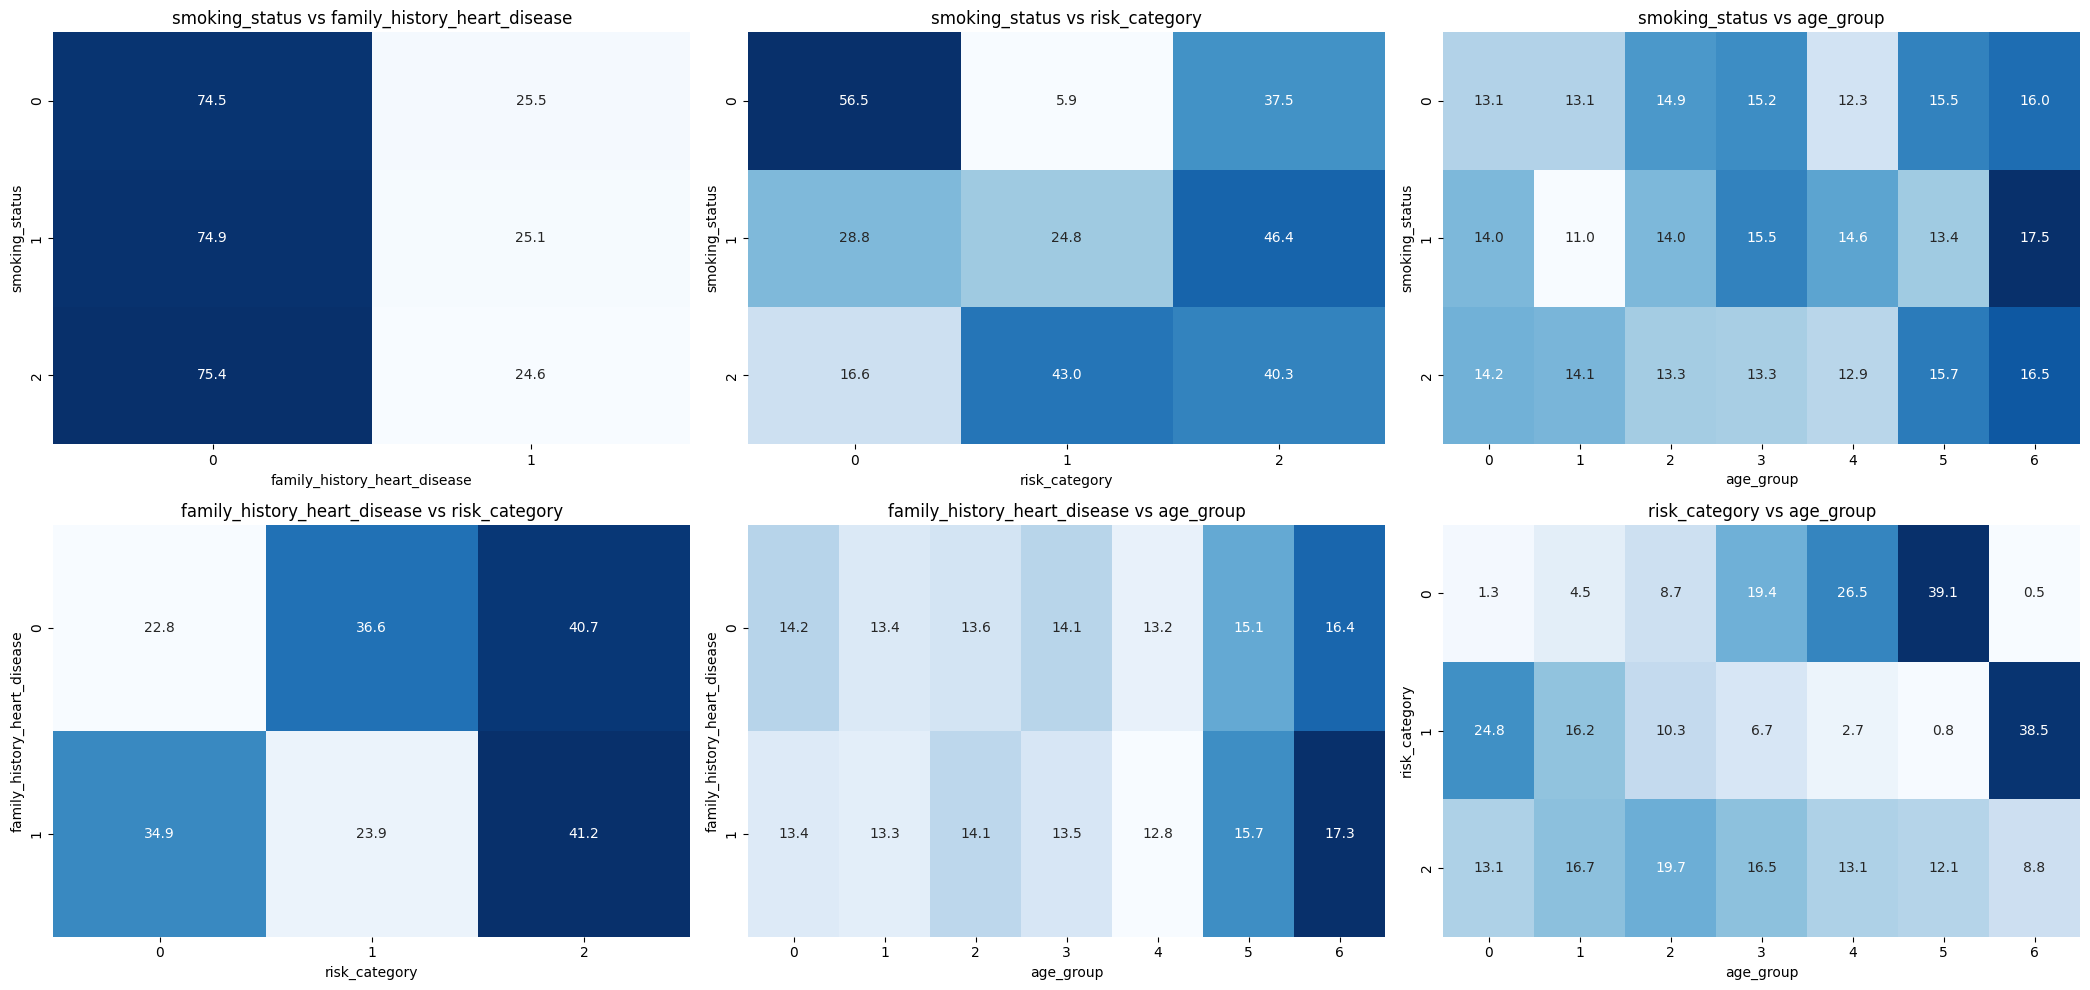

In [58]:
# Buat semua pasangan variabel kategorik
pairs = []

for i in range(len(kolom_kategorik)):
    for j in range(i + 1, len(kolom_kategorik)):
        pairs.append((kolom_kategorik[i], kolom_kategorik[j]))

n_cols = 3
n_rows = math.ceil(len(pairs) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(21, 5 * n_rows))
axes = axes.flatten()

for idx, (col1, col2) in enumerate(pairs):
    crosstab_pct = pd.crosstab(
        df_clean[col1],
        df_clean[col2],
        normalize='index'
    ) * 100

    sns.heatmap(
        crosstab_pct,
        annot=True,
        fmt='.1f',
        cmap='Blues',
        ax=axes[idx],
        cbar=False
    )

    axes[idx].set_title(f'{col1} vs {col2}')
    axes[idx].set_xlabel(col2)
    axes[idx].set_ylabel(col1)

# Hapus subplot kosong
for j in range(len(pairs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* `smoking_status` dan `family_history_heart_disease` memiliki pola yang hampir sama di setiap kategori.
* Hal ini menunjukkan bahwa status merokok tidak terlalu berkaitan dengan riwayat keluarga penyakit jantung.
* `smoking_status` terlihat memiliki hubungan dengan `risk_category`.
* Kelompok perokok cenderung memiliki proporsi risiko yang lebih tinggi dibandingkan kelompok tidak merokok.
* `family_history_heart_disease` juga berhubungan dengan `risk_category`.
* Pasien dengan riwayat keluarga penyakit jantung cenderung memiliki proporsi risiko tinggi yang lebih besar.
* `risk_category` memiliki pola yang berbeda pada setiap `age_group`.
* Kelompok usia tertentu memiliki proporsi risiko yang lebih tinggi dibandingkan kelompok usia lainnya.
* Secara umum, variabel yang paling terlihat berkaitan dengan kategori risiko adalah `smoking_status`, `family_history_heart_disease`, dan `age_group`.
* Pastikan angka kategori seperti 0, 1, dan 2 dijelaskan menggunakan keterangan label agar interpretasi lebih mudah dipahami.


### Korelasi Varibel Katagorik dengan Target Katagorik

In [59]:
kolom_kategorik = [
    'smoking_status',
    'stress_level',
    'family_history_heart_disease',
    'diet_quality_score'
]

target = 'risk_category'

In [60]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

kolom_kategorik = [
    'smoking_status',
    'stress_level',
    'family_history_heart_disease',
    'diet_quality_score'
]

target = 'risk_category'

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cramers_results = []

for col in kolom_kategorik:
    score = cramers_v(df_clean[col], df_clean[target])

    cramers_results.append({
        'Categorical Variable': col,
        "Cramer's V": round(score, 3)
    })

cramers_df = pd.DataFrame(cramers_results)
cramers_df = cramers_df.sort_values(by="Cramer's V", ascending=False)

display(cramers_df)

,Categorical Variable,Cramer's V
3,diet_quality_score,0.355
0,smoking_status,0.276
1,stress_level,0.235
2,family_history_heart_disease,0.140


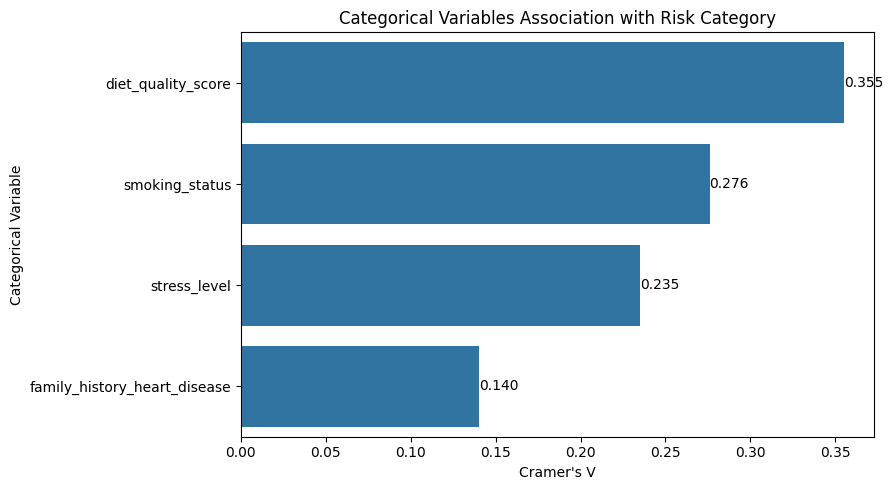

In [61]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=cramers_df,
    x="Cramer's V",
    y='Categorical Variable'
)

plt.title("Categorical Variables Association with Risk Category")
plt.xlabel("Cramer's V")
plt.ylabel("Categorical Variable")

for i, value in enumerate(cramers_df["Cramer's V"]):
    plt.text(
        value,
        i,
        f'{value:.3f}',
        va='center',
        ha='left'
    )

plt.tight_layout()
plt.show()

### Korelasi Varibel Katagorik dengan Target Numerik

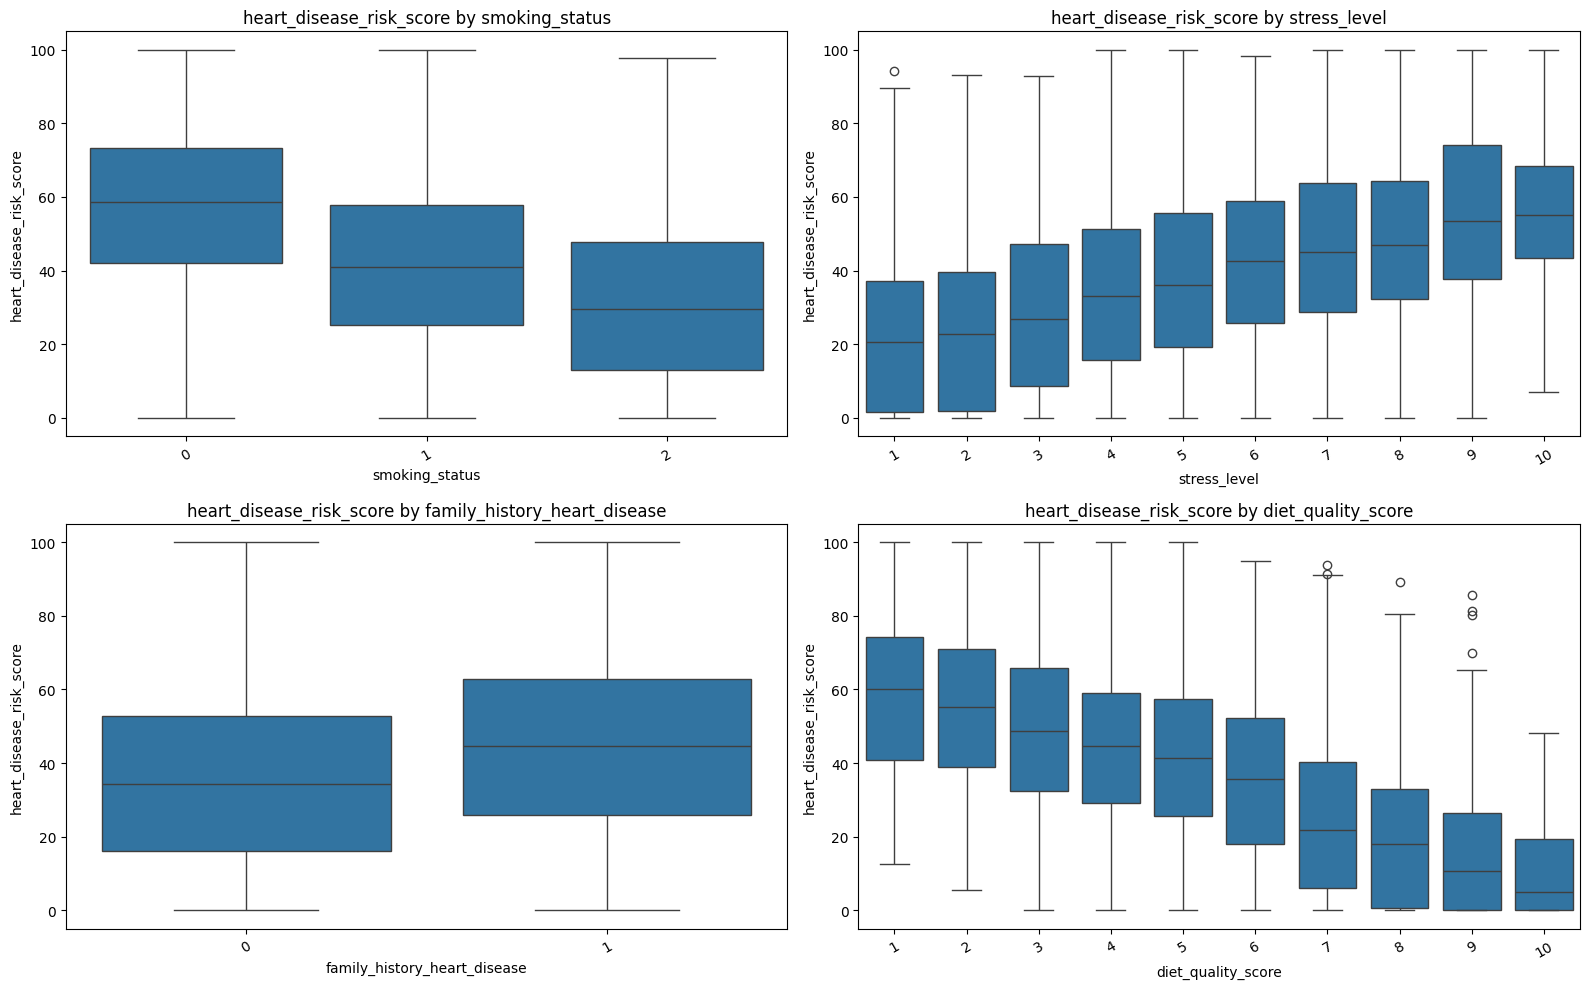

In [62]:
kolom_kategorik = [
    'smoking_status',
    'stress_level',
    'family_history_heart_disease',
    'diet_quality_score'
]

target = 'heart_disease_risk_score'

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(kolom_kategorik):
    sns.boxplot(
        data=df_clean,
        x=col,
        y=target,
        ax=axes[i]
    )

    axes[i].set_title(f'{target} by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

* Variabel `diet_quality_score` memiliki hubungan paling kuat dengan `risk_category`, dengan nilai **Cramer's V = 0,355**.
* Hal ini menunjukkan bahwa kualitas diet cukup berkaitan dengan kategori risiko kardiovaskular.
* Variabel `smoking_status` memiliki hubungan sebesar **0,276**, sehingga status merokok juga cukup berhubungan dengan kategori risiko.
* Variabel `stress_level` memiliki hubungan sebesar **0,235**, menunjukkan bahwa tingkat stres juga berkaitan dengan risiko kardiovaskular.
* Variabel `family_history_heart_disease` memiliki hubungan paling lemah, yaitu **0,140**.
* Secara umum, variabel kategorik yang paling berhubungan dengan kategori risiko adalah **kualitas diet, status merokok, dan tingkat stres**.


# EDA untuk Pertanyaan Bisnis

## Business Questions
1.	Berapa persentase pasien pada setiap kategori risiko kardiovaskular (Low, Medium, dan High) dalam dataset?

2.	Kelompok usia mana yang memiliki proporsi pasien High Risk paling besar?

3.	Bagaimana rata-rata tekanan darah, kadar kolesterol, dan heart_disease_risk_score pada setiap kategori risiko?

4.	Bagaimana pola gaya hidup pasien berdasarkan kategori risiko, dilihat dari aktivitas fisik, jumlah langkah harian, durasi tidur, kualitas diet, dan konsumsi alkohol?

5.	Bagaimana proporsi status merokok dan riwayat keluarga penyakit jantung pada setiap kategori risiko?

6.	Fitur klinis dan gaya hidup apa yang paling menonjol pada pasien kategori High Risk berdasarkan hasil EDA?

7.	Kelompok pasien mana yang perlu diprioritaskan dalam edukasi dan pencegahan penyakit jantung?

1. Berapa persentase pasien pada setiap kategori risiko kardiovaskular Low, Medium, dan High dalam dataset cardiovascular risk?

2. Kelompok usia mana yang memiliki proporsi pasien High Risk paling besar dalam dataset cardiovascular risk?

3. Kategori risiko mana yang memiliki rata-rata heart_disease_risk_score tertinggi dalam dataset cardiovascular risk?

4. Berapa rata-rata tekanan darah sistolik dan diastolik pada pasien kategori Low, Medium, dan High?

5. Berapa rata-rata kadar kolesterol pada setiap kategori risiko kardiovaskular?

6. Berapa rata-rata aktivitas fisik, jumlah langkah harian, durasi tidur, kualitas diet, dan konsumsi alkohol pada setiap kategori risiko?

7. Berapa proporsi pasien dengan status merokok Current, Former, dan Never pada setiap kategori risiko kardiovaskular?

8. Berapa proporsi pasien dengan riwayat keluarga penyakit jantung pada kategori Low, Medium, dan High?

9. Fitur klinis dan gaya hidup apa yang paling menonjol pada pasien dengan kategori High Risk berdasarkan hasil EDA?

10. Kelompok pasien mana yang perlu menjadi prioritas edukasi pencegahan berdasarkan kategori risiko, tekanan darah, kolesterol, aktivitas fisik, dan riwayat keluarga?

11. Seberapa besar pengaruh faktor gaya hidup terhadap peningkatan risiko penyakit jantung?

12. Bagaimana karakteristik individu dengan risiko tinggi dibandingkan dengan risiko rendah dan sedang?

### 1.Berapa persentase pasien pada setiap kategori risiko kardiovaskular Low, Medium, dan High dalam dataset cardiovascular risk?

,Risk Category,Count,Percentage (%)
0,Low,1838,33.42
1,Medium,2244,40.80
2,High,1418,25.78


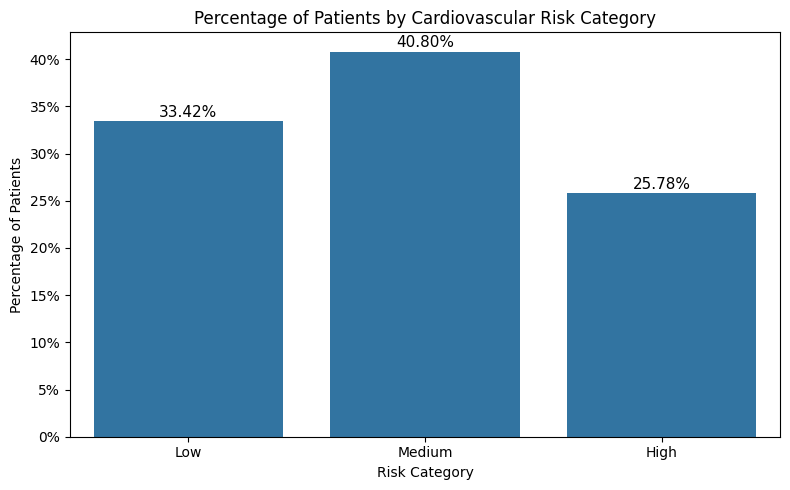

In [39]:
risk_order = ['Low', 'Medium', 'High']

risk_counts = df_clean['risk_category'].value_counts().reindex(risk_order)
risk_percentage = (risk_counts / risk_counts.sum() * 100).round(2)

risk_distribution = pd.DataFrame({
    'Risk Category': risk_order,
    'Count': risk_counts.values,
    'Percentage (%)': risk_percentage.values
})

display(risk_distribution)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=risk_distribution,
    x='Risk Category',
    y='Percentage (%)'
)

plt.title('Percentage of Patients by Cardiovascular Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Percentage of Patients')
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i, value in enumerate(risk_distribution['Percentage (%)']):
    plt.text(
        i,
        value + 0.5,
        f'{value:.2f}%',
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

**Insight**

- Kategori risiko terbanyak adalah **Medium Risk** sebesar **40.80%**.
- Kategori **Low Risk** sebesar **33.42%**.
- Kategori **High Risk** sebesar **25.78%**.
- Mayoritas pasien berada pada tingkat risiko **sedang**.
- Kelompok **High Risk** tetap perlu menjadi prioritas perhatian meskipun jumlahnya paling kecil.

### 2.Kelompok usia mana yang memiliki proporsi pasien High Risk paling besar dalam dataset cardiovascular risk?

/tmp/ipykernel_10994/2149912408.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('age_group')
/tmp/ipykernel_10994/2149912408.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_by_age = df_clean.groupby('age_group').size()


,Age Group,High Risk Percentage (%),High Risk Count,Total Patients
0,<30,0.77,7,912
1,30-39,2.47,19,768
2,40-49,8.68,64,737
3,50-59,16.29,123,755
4,60-69,35.76,275,769
5,70-79,52.29,376,719
6,80+,65.95,554,840


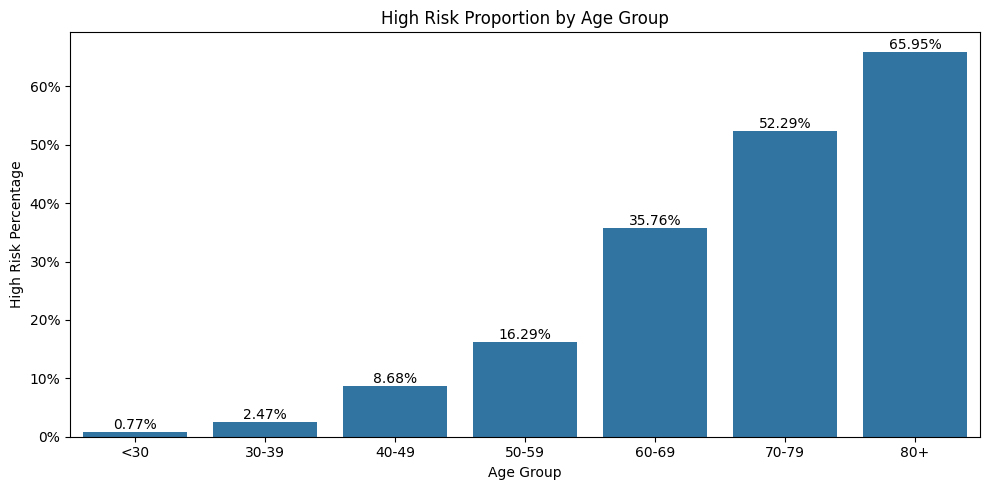

In [40]:
# Membuat kelompok usia
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0, 30, 40, 50, 60, 70, 80, 100],
    labels=['<30', '30-39', '40-49', '50-59', '60-69', '70-79', '80+'],
    right=False
)

# Menghitung jumlah pasien High Risk per kelompok usia
high_risk_by_age = (
    df_clean[df_clean['risk_category'] == 'High']
    .groupby('age_group')
    .size()
)

# Menghitung total pasien per kelompok usia
total_by_age = df_clean.groupby('age_group').size()

# Menghitung proporsi High Risk per kelompok usia
high_risk_percentage = (high_risk_by_age / total_by_age * 100).fillna(0).round(2)

# Membuat dataframe ringkasan
high_risk_age_df = pd.DataFrame({
    'Age Group': high_risk_percentage.index,
    'High Risk Percentage (%)': high_risk_percentage.values,
    'High Risk Count': high_risk_by_age.reindex(high_risk_percentage.index).fillna(0).astype(int).values,
    'Total Patients': total_by_age.reindex(high_risk_percentage.index).values
})

display(high_risk_age_df)

# Visualisasi
plt.figure(figsize=(10, 5))

sns.barplot(
    data=high_risk_age_df,
    x='Age Group',
    y='High Risk Percentage (%)'
)

plt.title('High Risk Proportion by Age Group')
plt.xlabel('Age Group')
plt.ylabel('High Risk Percentage')
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i, value in enumerate(high_risk_age_df['High Risk Percentage (%)']):
    plt.text(
        i,
        value + 0.5,
        f'{value:.2f}%',
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Insight**

- Proporsi **High Risk** paling besar terdapat pada kelompok usia **80+** sebesar **65.95%**.
- Kelompok usia **70–79** memiliki proporsi High Risk sebesar **52.29%**.
- Kelompok usia **60–69** mulai menunjukkan peningkatan signifikan, yaitu **35.76%**.
- Semakin tinggi kelompok usia, semakin besar proporsi pasien dengan kategori **High Risk**.
- Kelompok usia **60 tahun ke atas** perlu menjadi prioritas perhatian dalam pencegahan risiko kardiovaskular.

### 3.Bagaimana rata-rata tekanan darah, kadar kolesterol, dan heart_disease_risk_score pada setiap kategori risiko?

,risk_category,systolic_bp,diastolic_bp,cholesterol_mg_dl,heart_disease_risk_score
0,Low,133.95,87.10,212.12,10.54
1,Medium,148.52,96.71,242.95,39.60
2,High,162.45,105.48,270.26,69.28


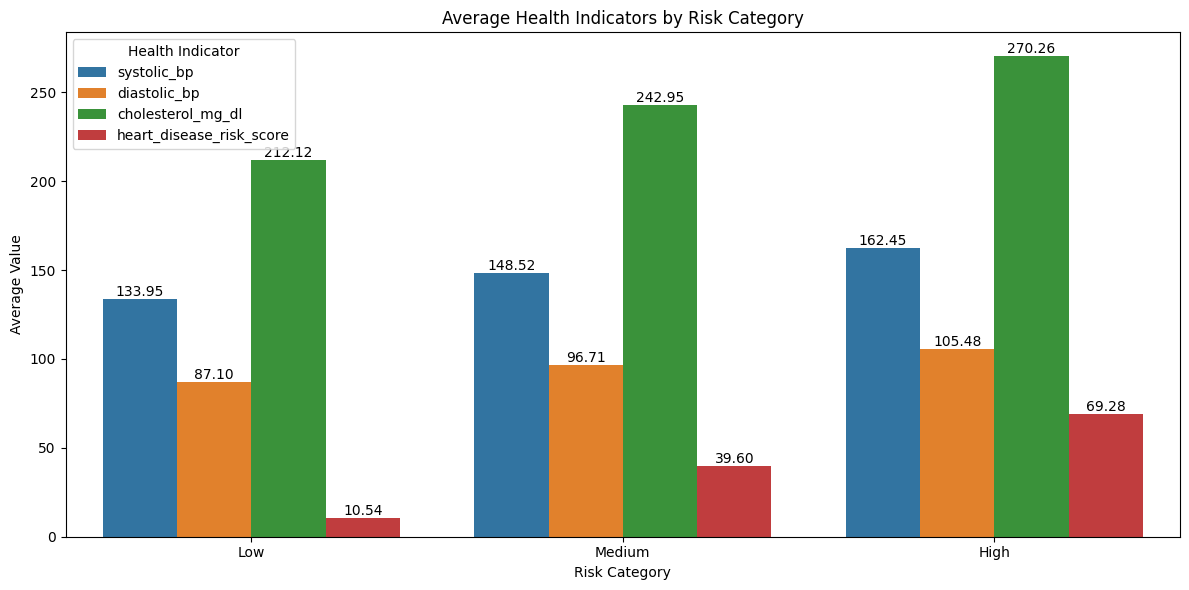

In [41]:
risk_order = ['Low', 'Medium', 'High']

avg_data = (
    df_clean
    .groupby('risk_category')[[
        'systolic_bp',
        'diastolic_bp',
        'cholesterol_mg_dl',
        'heart_disease_risk_score'
    ]]
    .mean()
    .reindex(risk_order)
    .round(2)
    .reset_index()
)

display(avg_data)

avg_data_melted = avg_data.melt(
    id_vars='risk_category',
    value_vars=[
        'systolic_bp',
        'diastolic_bp',
        'cholesterol_mg_dl',
        'heart_disease_risk_score'
    ],
    var_name='Health Indicator',
    value_name='Average Value'
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=avg_data_melted,
    x='risk_category',
    y='Average Value',
    hue='Health Indicator'
)

plt.title('Average Health Indicators by Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Average Value')

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f')

plt.legend(title='Health Indicator')

plt.tight_layout()
plt.show()

**Insight**

* Rata-rata `systolic_bp` meningkat dari Low (133.95), Medium (148.52), hingga High (162.45).
* Rata-rata `diastolic_bp` juga meningkat dari Low (87.10), Medium (96.71), hingga High (105.48).
* Rata-rata kolesterol meningkat dari Low (212.12 mg/dL), Medium (242.95 mg/dL), hingga High (270.26 mg/dL).
* Rata-rata `heart_disease_risk_score` meningkat dari Low (10.54), Medium (39.60), hingga High (69.28).
* Kategori High Risk memiliki rata-rata tekanan darah, kolesterol, dan skor risiko paling tinggi.
* Kategori Low Risk memiliki rata-rata tekanan darah, kolesterol, dan skor risiko paling rendah.
* Pola ini menunjukkan bahwa tekanan darah, kadar kolesterol, dan skor risiko penyakit jantung cenderung meningkat seiring meningkatnya kategori risiko kardiovaskular.
* Hasil ini juga menunjukkan bahwa `risk_category` sudah selaras dengan nilai `heart_disease_risk_score`.


### 4.Bagaimana pola gaya hidup pasien berdasarkan kategori risiko, dilihat dari aktivitas fisik, jumlah langkah harian, durasi tidur, kualitas diet, dan konsumsi alkohol?

,risk_category,physical_activity_hours_per_week,daily_steps,sleep_hours,diet_quality_score,alcohol_units_per_week
0,Low,4.94,7577.50,6.97,6.53,2.61
1,Medium,2.93,5588.61,6.88,4.98,3.83
2,High,1.75,4218.45,6.72,3.68,4.69


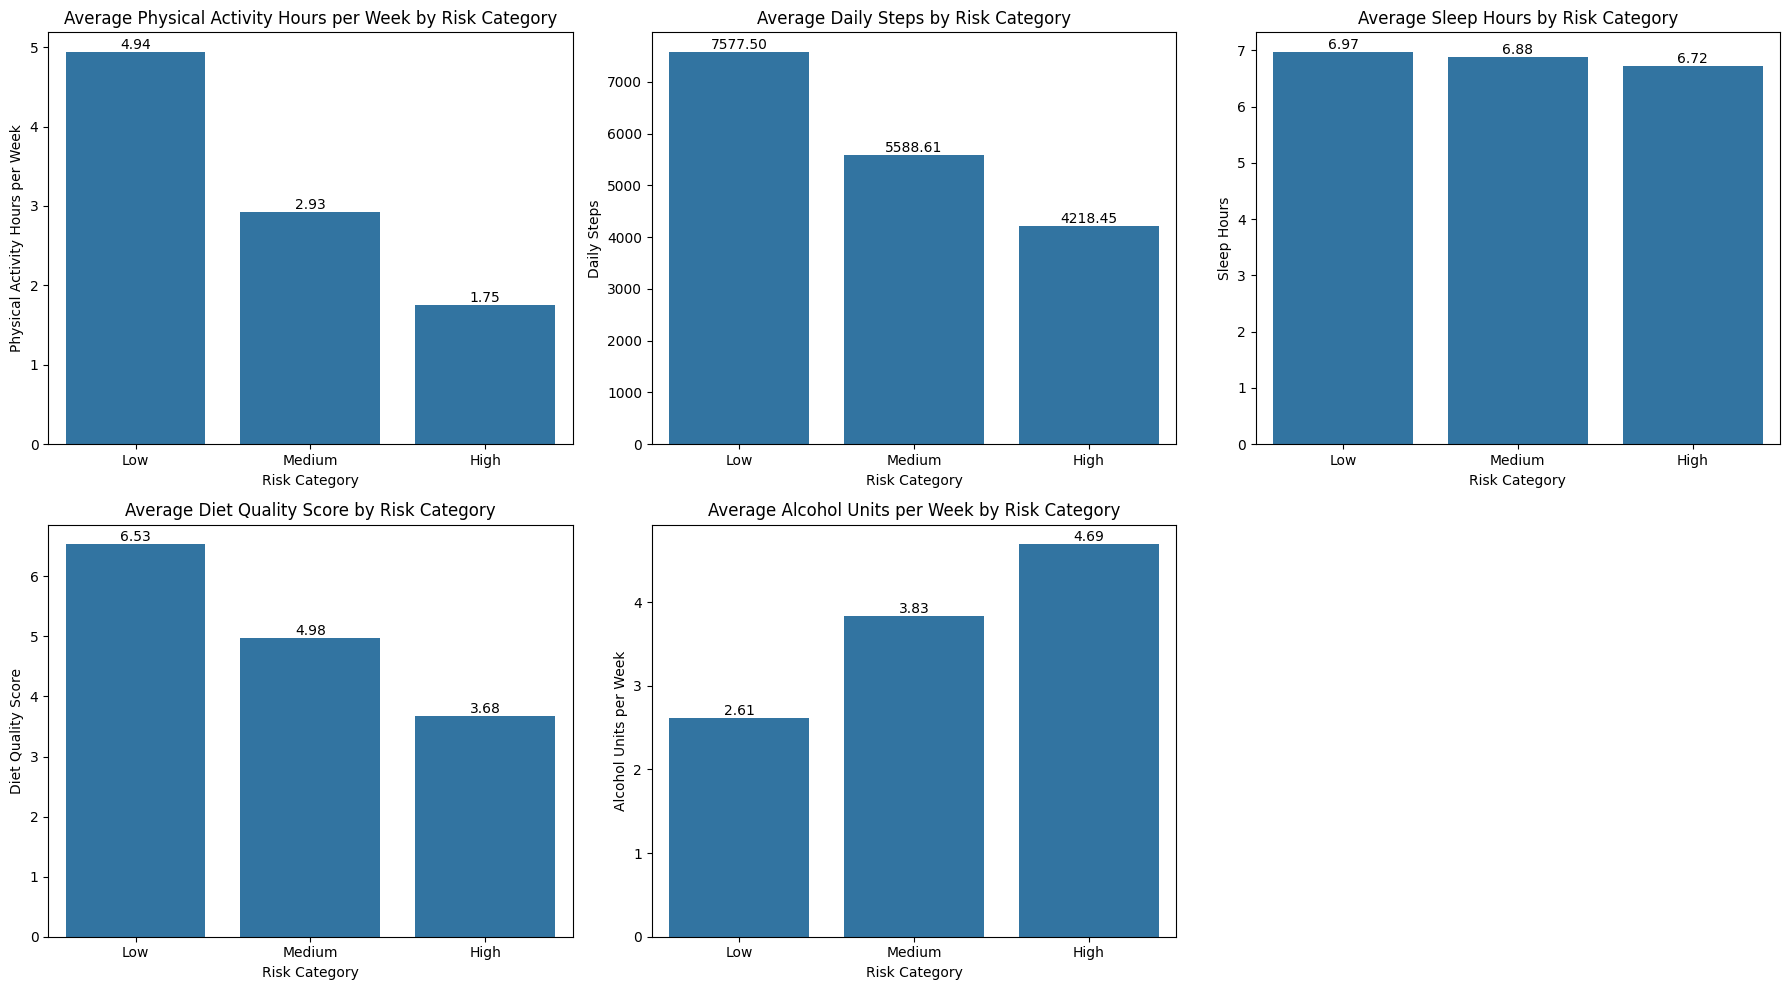

In [42]:
risk_order = ['Low', 'Medium', 'High']

lifestyle_cols = [
    'physical_activity_hours_per_week',
    'daily_steps',
    'sleep_hours',
    'diet_quality_score',
    'alcohol_units_per_week'
]

avg_lifestyle = (
    df_clean
    .groupby('risk_category')[lifestyle_cols]
    .mean()
    .reindex(risk_order)
    .round(2)
    .reset_index()
)

display(avg_lifestyle)


label_map = {
    'physical_activity_hours_per_week': 'Physical Activity Hours per Week',
    'daily_steps': 'Daily Steps',
    'sleep_hours': 'Sleep Hours',
    'diet_quality_score': 'Diet Quality Score',
    'alcohol_units_per_week': 'Alcohol Units per Week'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(lifestyle_cols):
    plot_data = avg_lifestyle[['risk_category', col]]

    sns.barplot(
        data=plot_data,
        x='risk_category',
        y=col,
        order=risk_order,
        ax=axes[i]
    )

    axes[i].set_title(f'Average {label_map[col]} by Risk Category')
    axes[i].set_xlabel('Risk Category')
    axes[i].set_ylabel(label_map[col])

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.2f')

for j in range(len(lifestyle_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Insight**

- Rata-rata **aktivitas fisik** menurun dari **Low (4.94 jam/minggu)** ke **High (1.75 jam/minggu)**.
- Rata-rata **daily steps** juga menurun dari **Low (7577.50 langkah)** ke **High (4218.45 langkah)**.
- Rata-rata **sleep hours** sedikit menurun dari **Low (6.97 jam)** ke **High (6.72 jam)**.
- Rata-rata **diet quality score** menurun dari **Low (6.53)** ke **High (3.68)**.
- Rata-rata **alcohol units per week** meningkat dari **Low (2.61)** ke **High (4.69)**.
- Pasien kategori **High Risk** cenderung memiliki aktivitas fisik lebih rendah, langkah harian lebih sedikit, kualitas diet lebih rendah, dan konsumsi alkohol lebih tinggi.

### 5.Bagaimana proporsi status merokok dan riwayat keluarga penyakit jantung pada setiap kategori risiko?

,Never,Former,Current,No,Yes
risk_category,,,,,
Low,1561,218,59,1512,326
Medium,1463,408,373,1681,563
High,603,253,562,941,477


smoking_status,Never,Former,Current
risk_category,,,
Low,84.93,11.86,3.21
Medium,65.20,18.18,16.62
High,42.52,17.84,39.63


family_history_heart_disease,No,Yes
risk_category,,
Low,82.26,17.74
Medium,74.91,25.09
High,66.36,33.64


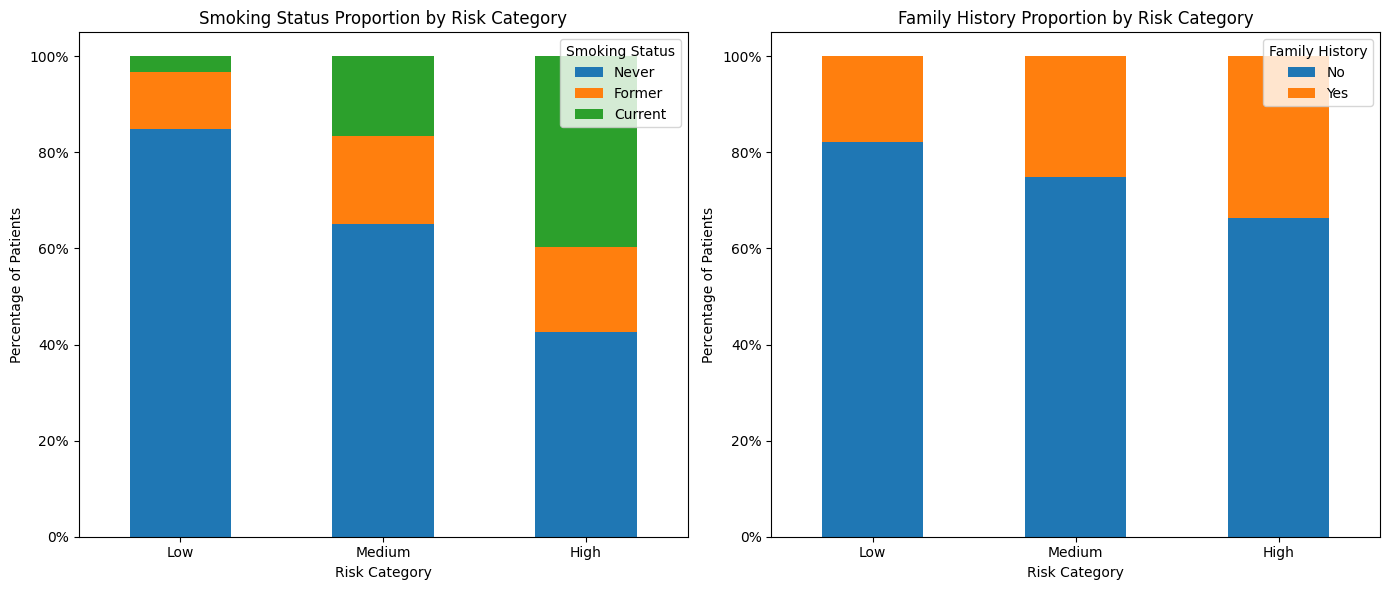

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

risk_order = ['Low', 'Medium', 'High']
smoking_order = ['Never', 'Former', 'Current']
family_order = ['No', 'Yes']

combined_count = pd.concat(
    [
        pd.crosstab(
            df_clean['risk_category'],
            df_clean['smoking_status']
        ).reindex(index=risk_order, columns=smoking_order),

        pd.crosstab(
            df_clean['risk_category'],
            df_clean['family_history_heart_disease']
        ).reindex(index=risk_order, columns=family_order)
    ],
    axis=1
)

display(combined_count)

smoking_pct = pd.crosstab(
    df_clean['risk_category'],
    df_clean['smoking_status'],
    normalize='index'
).reindex(index=risk_order, columns=smoking_order) * 100

family_pct = pd.crosstab(
    df_clean['risk_category'],
    df_clean['family_history_heart_disease'],
    normalize='index'
).reindex(index=risk_order, columns=family_order) * 100

smoking_pct = smoking_pct.round(2)
family_pct = family_pct.round(2)

display(smoking_pct)
display(family_pct)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

smoking_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[0]
)

axes[0].set_title('Smoking Status Proportion by Risk Category')
axes[0].set_xlabel('Risk Category')
axes[0].set_ylabel('Percentage of Patients')
axes[0].yaxis.set_major_formatter(PercentFormatter(decimals=0))
axes[0].legend(title='Smoking Status')
axes[0].tick_params(axis='x', rotation=0)

family_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1]
)

axes[1].set_title('Family History Proportion by Risk Category')
axes[1].set_xlabel('Risk Category')
axes[1].set_ylabel('Percentage of Patients')
axes[1].yaxis.set_major_formatter(PercentFormatter(decimals=0))
axes[1].legend(title='Family History')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Insight**

* Pada kategori Low Risk, mayoritas pasien berstatus *Never smoker* dan tidak memiliki riwayat keluarga penyakit jantung.
* Pada kategori Medium Risk, proporsi *Never smoker* masih paling besar, tetapi mulai menurun dibanding kategori Low Risk.
* Pada kategori High Risk, proporsi *Current smoker* meningkat paling besar dibanding kategori lain.
* Proporsi pasien dengan riwayat keluarga penyakit jantung (*Yes*) meningkat dari Low → Medium → High.
* Proporsi *Never smoker* menurun seiring meningkatnya kategori risiko.
* Proporsi pasien tanpa riwayat keluarga penyakit jantung menurun pada kategori risiko yang lebih tinggi.
* Kategori High Risk memiliki proporsi perokok aktif dan riwayat keluarga penyakit jantung paling besar.
* Pola ini menunjukkan bahwa kebiasaan merokok aktif dan riwayat keluarga penyakit jantung lebih banyak ditemukan pada pasien kategori High Risk.


### 6.Fitur klinis dan gaya hidup apa yang paling menonjol pada pasien kategori High Risk berdasarkan hasil EDA?

In [44]:
risk_order = ['Low', 'Medium', 'High']

feature_cols = [
    'age',
    'bmi',
    'systolic_bp',
    'diastolic_bp',
    'cholesterol_mg_dl',
    'resting_heart_rate',
    'daily_steps',
    'physical_activity_hours_per_week',
    'sleep_hours',
    'diet_quality_score',
    'alcohol_units_per_week'
]

# Rata-rata setiap fitur berdasarkan kategori risiko
avg_features_by_risk = (
    df_clean
    .groupby('risk_category')[feature_cols]
    .mean()
    .reindex(risk_order)
    .round(2)
)

display(avg_features_by_risk)

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week
risk_category,,,,,,,,,,,
Low,37.04,24.80,133.95,87.10,212.12,70.96,7577.50,4.94,6.97,6.53,2.61
Medium,55.53,28.60,148.52,96.71,242.95,74.67,5588.61,2.93,6.88,4.98,3.83
High,73.07,31.87,162.45,105.48,270.26,77.20,4218.45,1.75,6.72,3.68,4.69


In [45]:
# Rata-rata fitur pada seluruh pasien
overall_mean = df_clean[feature_cols].mean()

# Rata-rata fitur pada pasien High Risk
high_risk_mean = df_clean[df_clean['risk_category'] == 'High'][feature_cols].mean()

# Selisih High Risk dibanding rata-rata keseluruhan
high_risk_comparison = pd.DataFrame({
    'Overall Mean': overall_mean,
    'High Risk Mean': high_risk_mean,
    'Difference': high_risk_mean - overall_mean,
    'Difference (%)': ((high_risk_mean - overall_mean) / overall_mean * 100)
}).round(2)

high_risk_comparison = high_risk_comparison.sort_values(
    by='Difference (%)',
    ascending=False
)

display(high_risk_comparison)

,Overall Mean,High Risk Mean,Difference,Difference (%)
age,53.87,73.07,19.20,35.64
alcohol_units_per_week,3.65,4.69,1.05,28.73
bmi,28.17,31.87,3.70,13.13
cholesterol_mg_dl,239.69,270.26,30.57,12.75
systolic_bp,147.24,162.45,15.21,10.33
diastolic_bp,95.76,105.48,9.72,10.15
resting_heart_rate,74.08,77.20,3.12,4.21
sleep_hours,6.87,6.72,-0.14,-2.11
daily_steps,5900.01,4218.45,-1681.56,-28.50
diet_quality_score,5.16,3.68,-1.48,-28.66


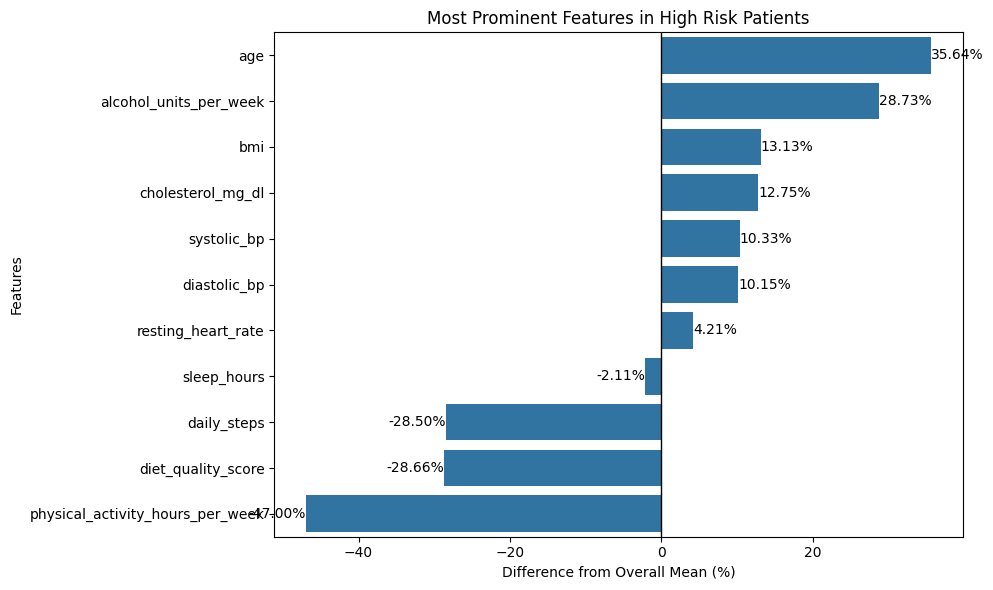

In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=high_risk_comparison.reset_index(),
    x='Difference (%)',
    y='index'
)

plt.axvline(0, color='black', linewidth=1)

plt.title('Most Prominent Features in High Risk Patients')
plt.xlabel('Difference from Overall Mean (%)')
plt.ylabel('Features')

for i, value in enumerate(high_risk_comparison['Difference (%)']):
    plt.text(
        value,
        i,
        f'{value:.2f}%',
        va='center',
        ha='left' if value >= 0 else 'right'
    )

plt.tight_layout()
plt.show()

**Insight**

- Fitur yang paling menonjol pada pasien **High Risk** adalah **age**, lebih tinggi **35.64%** dari rata-rata keseluruhan.
- **Alcohol units per week** juga lebih tinggi **28.73%** pada pasien High Risk.
- Fitur klinis seperti **BMI**, **cholesterol**, **systolic BP**, dan **diastolic BP** lebih tinggi pada pasien High Risk.
- **Physical activity hours per week** lebih rendah **47.00%** dibanding rata-rata keseluruhan.
- **Diet quality score** lebih rendah **28.66%** pada pasien High Risk.
- **Daily steps** lebih rendah **28.50%** pada pasien High Risk.
- Pasien **High Risk** cenderung lebih tua, konsumsi alkohol lebih tinggi, aktivitas fisik lebih rendah, pola makan lebih buruk, dan indikator klinis lebih tinggi.

### 7.Kelompok pasien mana yang perlu menjadi prioritas edukasi pencegahan berdasarkan kategori risiko, tekanan darah, kolesterol, aktivitas fisik, dan riwayat keluarga?

In [47]:
# Membuat salinan data
priority_df = df_clean.copy()

# Menentukan kondisi prioritas
priority_df['priority_group'] = 'Low Priority'

priority_df.loc[
    (
        (priority_df['risk_category'] == 'High') |
        (priority_df['systolic_bp'] >= 140) |
        (priority_df['diastolic_bp'] >= 90) |
        (priority_df['cholesterol_mg_dl'] >= 240) |
        (priority_df['physical_activity_hours_per_week'] < 2) |
        (priority_df['family_history_heart_disease'] == 'Yes')
    ),
    'priority_group'
] = 'Need Education Priority'

# Menampilkan jumlah dan persentase kelompok prioritas
priority_summary = pd.DataFrame({
    'Count': priority_df['priority_group'].value_counts(),
    'Percentage (%)': round(priority_df['priority_group'].value_counts(normalize=True) * 100, 2)
})

display(priority_summary)

,Count,Percentage (%)
priority_group,,
Need Education Priority,4822,87.67
Low Priority,678,12.33


In [48]:
priority_profile = (
    priority_df
    .groupby('priority_group')[
        [
            'systolic_bp',
            'diastolic_bp',
            'cholesterol_mg_dl',
            'physical_activity_hours_per_week',
            'heart_disease_risk_score'
        ]
    ]
    .mean()
    .round(2)
)

display(priority_profile)

,systolic_bp,diastolic_bp,cholesterol_mg_dl,physical_activity_hours_per_week,heart_disease_risk_score
priority_group,,,,,
Low Priority,129.15,83.00,203.82,6.01,4.46
Need Education Priority,149.79,97.55,244.73,2.91,42.19


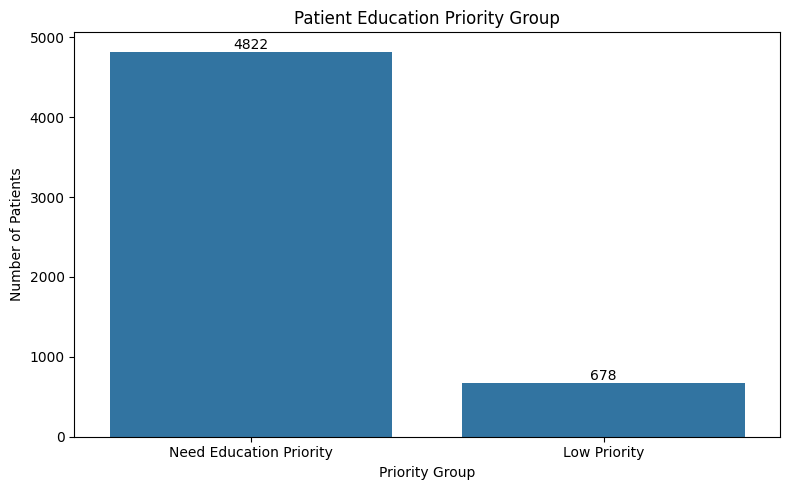

In [49]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=priority_df,
    x='priority_group'
)

plt.title('Patient Education Priority Group')
plt.xlabel('Priority Group')
plt.ylabel('Number of Patients')

for container in plt.gca().containers:
    plt.gca().bar_label(container)

plt.tight_layout()
plt.show()

**Insight**

- Sebanyak **4.822 pasien** masuk kelompok **Need Education Priority**.
- Sebanyak **678 pasien** masuk kelompok **Low Priority**.
- Mayoritas pasien membutuhkan edukasi pencegahan kardiovaskular.
- Kelompok prioritas edukasi jauh lebih besar dibanding kelompok prioritas rendah.
- Edukasi pencegahan perlu difokuskan pada pasien dengan risiko tinggi, tekanan darah tinggi, kolesterol tinggi, aktivitas fisik rendah, atau riwayat keluarga penyakit jantung.

# **FITUR ENGINEERING**

In [50]:
# Cek data clean
display(df_clean.head())
print("Ukuran data clean:", df_clean.shape)

# Simpan data clean
df_clean.to_csv('cardiovascular_risk_dataset_clean.csv', index=False)

# Download data clean
from google.colab import files
files.download('cardiovascular_risk_dataset_clean.csv')

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category,age_group
0,1,62,25.0,142,93.0,247,72.0,Never,11565,3,5.6,8.2,No,7,0.70,28.1,Medium,60-69
1,2,54,29.7,158,101.0,254,74.0,Current,4036,8,0.5,6.7,No,5,4.50,63.0,High,50-59
2,3,46,36.2,170,113.0,276,80.0,Current,3043,9,0.4,4.1,No,1,11.45,73.1,High,40-49
3,4,48,30.4,153,98.0,230,73.0,Former,5604,5,0.6,8.0,No,4,8.50,39.5,Medium,40-49
4,5,46,25.3,139,87.0,206,69.0,Current,7464,1,2.0,6.1,No,5,3.60,29.3,Medium,40-49


Ukuran data clean: (5500, 18)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Patient_ID                        5500 non-null   int64   
 1   age                               5500 non-null   int64   
 2   bmi                               5500 non-null   float64 
 3   systolic_bp                       5500 non-null   int64   
 4   diastolic_bp                      5500 non-null   float64 
 5   cholesterol_mg_dl                 5500 non-null   int64   
 6   resting_heart_rate                5500 non-null   float64 
 7   smoking_status                    5500 non-null   object  
 8   daily_steps                       5500 non-null   int64   
 9   stress_level                      5500 non-null   int64   
 10  physical_activity_hours_per_week  5500 non-null   float64 
 11  sleep_hours                       5500 non-null   float6

### ENCODING

In [52]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Kolom kategorik yang akan diubah langsung
kolom_kategorik = [
    'smoking_status',
    'family_history_heart_disease',
    'risk_category',
    'age_group'
]

# Dictionary untuk menyimpan mapping encoding
encoding_mapping = {}

for col in kolom_kategorik:
    le = LabelEncoder()

    # Simpan mapping sebelum kolom diganti
    le.fit(df_clean[col].astype(str))
    encoding_mapping[col] = {
        label: int(code) for label, code in zip(le.classes_, le.transform(le.classes_))
    }

    # Ubah langsung kolom aslinya
    df_clean[col] = le.transform(df_clean[col].astype(str))

# Tampilkan mapping encoding
for col, mapping in encoding_mapping.items():
    print(f"\nEncoding untuk kolom: {col}")
    for label, code in mapping.items():
        print(f"{code} = {label}")


Encoding untuk kolom: smoking_status
0 = Current
1 = Former
2 = Never

Encoding untuk kolom: family_history_heart_disease
0 = No
1 = Yes

Encoding untuk kolom: risk_category
0 = High
1 = Low
2 = Medium

Encoding untuk kolom: age_group
0 = 30-39
1 = 40-49
2 = 50-59
3 = 60-69
4 = 70-79
5 = 80+
6 = <30


In [53]:
df_clean.head()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category,age_group
0,1,62,25.0,142,93.0,247,72.0,2,11565,3,5.6,8.2,0,7,0.70,28.1,2,3
1,2,54,29.7,158,101.0,254,74.0,0,4036,8,0.5,6.7,0,5,4.50,63.0,0,2
2,3,46,36.2,170,113.0,276,80.0,0,3043,9,0.4,4.1,0,1,11.45,73.1,0,1
3,4,48,30.4,153,98.0,230,73.0,1,5604,5,0.6,8.0,0,4,8.50,39.5,2,1
4,5,46,25.3,139,87.0,206,69.0,0,7464,1,2.0,6.1,0,5,3.60,29.3,2,1


### Membuat FItur Baru

## Feature Engineering

Feature engineering dilakukan untuk membuat fitur tambahan dari kolom yang sudah tersedia. Tujuannya adalah membantu model memahami pola risiko kardiovaskular dengan lebih baik, terutama dari sisi tekanan darah, BMI, kolesterol, aktivitas fisik, kualitas tidur, konsumsi alkohol, dan kombinasi faktor risiko klinis maupun gaya hidup.

### Fitur Baru yang Dibuat

| No | Nama Fitur | Deskripsi | Keterangan Nilai |
|---|---|---|---|
| 1 | `pulse_pressure` | Selisih antara tekanan darah sistolik dan diastolik. | Semakin tinggi nilainya, semakin besar perbedaan tekanan darah. |
| 2 | `blood_pressure_ratio` | Rasio antara tekanan darah sistolik dan diastolik. | Digunakan untuk melihat perbandingan tekanan darah pasien. |
| 3 | `hypertension_stage` | Kategori tingkat hipertensi berdasarkan tekanan darah sistolik dan diastolik. | 0 = Normal, 1 = Elevated, 2 = Hypertension Stage 1, 3 = Hypertension Stage 2 |
| 4 | `bmi_category` | Kategori BMI pasien berdasarkan nilai `bmi`. | 0 = Underweight, 1 = Normal, 2 = Overweight, 3 = Obese |
| 5 | `cholesterol_category` | Kategori kadar kolesterol pasien berdasarkan nilai `cholesterol_mg_dl`. | 0 = Normal, 1 = Borderline High, 2 = High |
| 6 | `activity_level` | Kategori tingkat aktivitas berdasarkan jumlah langkah harian. | 0 = Low Activity, 1 = Moderate Activity, 2 = High Activity |
| 7 | `sleep_category` | Kategori durasi tidur pasien berdasarkan `sleep_hours`. | 0 = Short Sleep, 1 = Normal Sleep, 2 = Long Sleep |
| 8 | `alcohol_category` | Kategori konsumsi alkohol mingguan berdasarkan `alcohol_units_per_week`. | 0 = Low, 1 = Moderate, 2 = High |
| 9 | `lifestyle_risk_score` | Skor gabungan faktor gaya hidup berisiko. | Semakin tinggi skor, semakin banyak indikator gaya hidup tidak sehat. |
| 10 | `clinical_risk_score` | Skor gabungan faktor klinis berisiko. | Semakin tinggi skor, semakin banyak indikator klinis yang berisiko. |

### Penjelasan Fitur Gabungan

#### `lifestyle_risk_score`

Fitur ini dibuat dari beberapa indikator gaya hidup, yaitu:

- Jumlah langkah harian rendah
- Aktivitas fisik mingguan rendah
- Durasi tidur kurang
- Kualitas diet rendah
- Konsumsi alkohol tinggi
- Status merokok aktif

Semakin tinggi nilai `lifestyle_risk_score`, semakin banyak faktor gaya hidup berisiko yang dimiliki pasien.

#### `clinical_risk_score`

Fitur ini dibuat dari beberapa indikator klinis, yaitu:

- BMI tinggi
- Tekanan darah sistolik tinggi
- Tekanan darah diastolik tinggi
- Kolesterol tinggi
- Resting heart rate tinggi
- Riwayat keluarga penyakit jantung

Semakin tinggi nilai `clinical_risk_score`, semakin banyak faktor klinis berisiko yang dimiliki pasien.

### Tujuan Feature Engineering

Feature engineering ini bertujuan untuk:

- Mengubah informasi numerik menjadi kategori yang lebih mudah dipahami.
- Menambahkan fitur gabungan yang merepresentasikan tingkat risiko klinis dan gaya hidup.
- Membantu model machine learning dalam mengenali pola risiko kardiovaskular.
- Meningkatkan interpretasi hasil analisis dan pemodelan.

In [54]:
# 1. Pulse Pressure
# Selisih tekanan darah sistolik dan diastolik
df_clean['pulse_pressure'] = df_clean['systolic_bp'] - df_clean['diastolic_bp']


# 2. Blood Pressure Ratio
# Rasio tekanan darah sistolik terhadap diastolik
df_clean['blood_pressure_ratio'] = df_clean['systolic_bp'] / df_clean['diastolic_bp']


# 3. Hypertension Stage
# 0 = Normal
# 1 = Elevated / mulai tinggi
# 2 = Hypertension Stage 1
# 3 = Hypertension Stage 2
def categorize_hypertension(row):
    if row['systolic_bp'] < 120 and row['diastolic_bp'] < 80:
        return 0
    elif row['systolic_bp'] < 130 and row['diastolic_bp'] < 80:
        return 1
    elif row['systolic_bp'] < 140 or row['diastolic_bp'] < 90:
        return 2
    else:
        return 3

df_clean['hypertension_stage'] = df_clean.apply(categorize_hypertension, axis=1)


# 4. BMI Category
# 0 = Underweight
# 1 = Normal
# 2 = Overweight
# 3 = Obese
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 0
    elif bmi < 25:
        return 1
    elif bmi < 30:
        return 2
    else:
        return 3

df_clean['bmi_category'] = df_clean['bmi'].apply(categorize_bmi)


# 5. Cholesterol Category
# 0 = Normal
# 1 = Borderline High
# 2 = High
def categorize_cholesterol(chol):
    if chol < 200:
        return 0
    elif chol < 240:
        return 1
    else:
        return 2

df_clean['cholesterol_category'] = df_clean['cholesterol_mg_dl'].apply(categorize_cholesterol)


# 6. Activity Level
# Berdasarkan jumlah langkah harian
# 0 = Low Activity
# 1 = Moderate Activity
# 2 = High Activity
def categorize_activity(steps):
    if steps < 5000:
        return 0
    elif steps < 10000:
        return 1
    else:
        return 2

df_clean['activity_level'] = df_clean['daily_steps'].apply(categorize_activity)


# 7. Sleep Category
# 0 = Short Sleep
# 1 = Normal Sleep
# 2 = Long Sleep
def categorize_sleep(hours):
    if hours < 6:
        return 0
    elif hours <= 8:
        return 1
    else:
        return 2

df_clean['sleep_category'] = df_clean['sleep_hours'].apply(categorize_sleep)


# 8. Alcohol Category
# 0 = Low
# 1 = Moderate
# 2 = High
def categorize_alcohol(units):
    if units < 3:
        return 0
    elif units <= 7:
        return 1
    else:
        return 2

df_clean['alcohol_category'] = df_clean['alcohol_units_per_week'].apply(categorize_alcohol)


# 9. Lifestyle Risk Score
# Semakin tinggi skor, semakin buruk gaya hidup
df_clean['lifestyle_risk_score'] = (
    (df_clean['daily_steps'] < 5000).astype(int) +
    (df_clean['physical_activity_hours_per_week'] < 2).astype(int) +
    (df_clean['sleep_hours'] < 6).astype(int) +
    (df_clean['diet_quality_score'] <= 4).astype(int) +
    (df_clean['alcohol_units_per_week'] > 7).astype(int) +
    (df_clean['smoking_status'] == 0).astype(int)
)


# 10. Clinical Risk Score
# Semakin tinggi skor, semakin banyak indikator klinis berisiko
df_clean['clinical_risk_score'] = (
    (df_clean['bmi'] >= 30).astype(int) +
    (df_clean['systolic_bp'] >= 140).astype(int) +
    (df_clean['diastolic_bp'] >= 90).astype(int) +
    (df_clean['cholesterol_mg_dl'] >= 240).astype(int) +
    (df_clean['resting_heart_rate'] >= 90).astype(int) +
    (df_clean['family_history_heart_disease'] == 1).astype(int)
)

df_clean.head()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,...,pulse_pressure,blood_pressure_ratio,hypertension_stage,bmi_category,cholesterol_category,activity_level,sleep_category,alcohol_category,lifestyle_risk_score,clinical_risk_score
0,1,62,25.0,142,93.0,247,72.0,2,11565,3,...,49.0,1.526882,3,2,2,2,2,0,0,3
1,2,54,29.7,158,101.0,254,74.0,0,4036,8,...,57.0,1.564356,3,2,2,0,1,1,3,3
2,3,46,36.2,170,113.0,276,80.0,0,3043,9,...,57.0,1.504425,3,3,2,0,0,2,6,4
3,4,48,30.4,153,98.0,230,73.0,1,5604,5,...,55.0,1.561224,3,3,1,1,1,2,3,3
4,5,46,25.3,139,87.0,206,69.0,0,7464,1,...,52.0,1.597701,2,2,1,1,1,1,1,0


In [55]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 28 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        5500 non-null   int64  
 1   age                               5500 non-null   int64  
 2   bmi                               5500 non-null   float64
 3   systolic_bp                       5500 non-null   int64  
 4   diastolic_bp                      5500 non-null   float64
 5   cholesterol_mg_dl                 5500 non-null   int64  
 6   resting_heart_rate                5500 non-null   float64
 7   smoking_status                    5500 non-null   int64  
 8   daily_steps                       5500 non-null   int64  
 9   stress_level                      5500 non-null   int64  
 10  physical_activity_hours_per_week  5500 non-null   float64
 11  sleep_hours                       5500 non-null   float64
 12  family

# SAVE DATA

In [56]:
output_path = '/content/cardiovascular_risk_dataset_feature_engineered.csv'
df_clean.to_csv(output_path, index=False)

# Download file
from google.colab import files
files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# UBAH JADI PDF

In [66]:
# Install package untuk export PDF
!apt-get update -qq
!apt-get install -y pandoc texlive-xetex texlive-fonts-recommended texlive-plain-generic > /dev/null

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
^C


In [67]:
# Ubah nama file sesuai nama notebook kamu
!jupyter nbconvert --to pdf "CLEANING_DATA.ipynb"

[NbConvertApp] Converting notebook CLEANING_DATA.ipynb to pdf
[NbConvertApp] Support files will be in CLEANING_DATA_files/
[NbConvertApp] Making directory ./CLEANING_DATA_files
[NbConvertApp] Writing 236628 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 2284487 bytes to CLEANING_DATA.pdf


In [68]:
!jupyter nbconvert --to html --no-input --embed-images "/content/CLEANING_DATA.ipynb" --output "/content/CLEANING_DATA_REPORT.html"

[NbConvertApp] Converting notebook /content/CLEANING_DATA.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 19 image(s).
[NbConvertApp] Writing 3670492 bytes to /content/CLEANING_DATA_REPORT.html
